# 🐟 Fish Price Market Analysis
### Merging Fuel · Fish Prices · Weather · Sri Lankan Holidays into a Master DataFrame
This notebook merges all key data sources by date, labels Sri Lankan monsoon seasons,
flags Poya/holiday days, and analyses how fuel price and weather drive fish prices.

## 1 · Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT       = Path(r"D:\reserch\final_year_research\model\dataset")
RAW        = ROOT / "raw"
PROCESSED  = ROOT / "processed"

FUEL_XLSX     = RAW / "fuel_price" / "Fuel Price.xlsx"
FISH_CSV      = PROCESSED / "merged_price.csv"           # pre-built: date, fish_id, sinhala_name, common_name, price
FESTIVALS_CSV = RAW / "festivals" / "festivals_2020_2026.csv"
WEATHER_CSV   = PROCESSED / "weather_dataset.csv"        # date, temp_c, humidity, wind_speed, rainfall, city

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded ✓")
print(f"Root data dir: {ROOT}")


Libraries loaded ✓
Root data dir: D:\reserch\final_year_research\model\dataset


## 2 · Load Raw Data Sources

In [2]:
# ── 2a. Fuel Price (LK Kerosene) from Excel ──────────────────────────────────
fuel_raw = pd.read_excel(FUEL_XLSX, header=None)

# Detect the LK column flexibly (handles Sinhala subtitle)
lk_col_idx = None
for col_idx in range(fuel_raw.shape[1]):
    col_vals = fuel_raw.iloc[:, col_idx].astype(str)
    if col_vals.str.contains("LK", case=False, na=False).any():
        lk_col_idx = col_idx
        break

if lk_col_idx is None:
    raise ValueError("Could not find LK column in Fuel Price.xlsx")

# Find the header row (row containing "Date" or "date")
date_col_idx = None
header_row_idx = None
for row_idx in range(min(10, len(fuel_raw))):
    row_vals = fuel_raw.iloc[row_idx].astype(str)
    if row_vals.str.contains("date", case=False, na=False).any():
        header_row_idx = row_idx
        date_col_idx   = row_vals.str.contains("date", case=False, na=False).idxmax()
        break

if header_row_idx is None:
    # Fallback – use column 0 as date, re-read with 2-row header skip
    header_row_idx = 0
    date_col_idx   = 0

fuel_raw2 = pd.read_excel(FUEL_XLSX, header=header_row_idx)
# Re-detect LK column by name now that headers are set
lk_candidates = [c for c in fuel_raw2.columns
                 if "lk" in str(c).lower() or "kerosene" in str(c).lower()
                 or "භූමිතෙල්" in str(c)]
if not lk_candidates:
    # Use positional fallback
    fuel_raw2.columns = [str(c) for c in fuel_raw2.columns]
    lk_col_name = fuel_raw2.columns[lk_col_idx]
else:
    lk_col_name = lk_candidates[0]

date_col_name_candidates = [c for c in fuel_raw2.columns
                             if "date" in str(c).lower()]
date_col_name = date_col_name_candidates[0] if date_col_name_candidates else fuel_raw2.columns[0]

fuel_raw2 = fuel_raw2[[date_col_name, lk_col_name]].copy()
fuel_raw2.columns = ["date", "lk_price"]
fuel_raw2 = fuel_raw2.dropna(subset=["date"])
fuel_raw2["date"]     = pd.to_datetime(fuel_raw2["date"], errors="coerce")
fuel_raw2["lk_price"] = pd.to_numeric(fuel_raw2["lk_price"], errors="coerce")
fuel_raw2 = fuel_raw2.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

print(f"Fuel rows loaded : {len(fuel_raw2):,}")
print(f"Date range       : {fuel_raw2['date'].min().date()}  →  {fuel_raw2['date'].max().date()}")
print(f"LK price range   : {fuel_raw2['lk_price'].min():.2f}  –  {fuel_raw2['lk_price'].max():.2f} LKR")
display(fuel_raw2.head())


Fuel rows loaded : 81
Date range       : 2003-04-09  →  2026-06-01
LK price range   : 23.00  –  365.00 LKR


,date,lk_price
0,2003-04-09,25.00
1,2003-04-12,25.50
2,2003-05-10,23.00
3,2003-07-08,24.00
4,2003-11-11,23.50


In [3]:
# ── 2b. Daily Fish Prices ──────────────────────────────────────────────────────
fish_df = pd.read_csv(FISH_CSV, parse_dates=["date"])
fish_df.rename(columns={"price": "fish_price"}, inplace=True)

# Aggregate to one avg price per date (across all species) for the master df
fish_daily = (
    fish_df.groupby("date")["fish_price"]
    .mean()
    .reset_index()
    .rename(columns={"fish_price": "avg_fish_price"})
)

print(f"Fish price rows  : {len(fish_daily):,}")
print(f"Date range       : {fish_daily['date'].min().date()}  →  {fish_daily['date'].max().date()}")
display(fish_daily.head())


Fish price rows  : 189
Date range       : 2021-08-08  →  2025-12-22


,date,avg_fish_price
0,2021-08-08,573.18
1,2021-08-15,577.70
2,2021-08-22,529.96
3,2021-09-01,543.18
4,2021-09-08,591.98


In [4]:
# ── 2c. Sri Lankan Holidays & Poya ────────────────────────────────────────────
fest_df = pd.read_csv(FESTIVALS_CSV)
fest_df["festival_date"] = pd.to_datetime(fest_df["festival_date"], errors="coerce")
fest_df = fest_df.dropna(subset=["festival_date"]).sort_values("festival_date").reset_index(drop=True)

# Tag Poya days separately
fest_df["is_poya"] = fest_df["festival_name"].str.contains("poya", case=False, na=False).astype(int)

print(f"Festival records : {len(fest_df):,}  ({fest_df['is_poya'].sum()} Poya days)")
display(fest_df.head(10))


Festival records : 80  (24 Poya days)


,festival_name,festival_date,is_poya
0,NewYear_Jan1,2020-01-01,0
1,Independence_Day,2020-02-04,0
2,SinhalaNewYear,2020-04-13,0
3,TamilNewYear,2020-04-14,0
4,SinhalaNewYear,2020-04-14,0
5,Eid_al_Fitr,2020-05-24,0
6,Eid_al_Adha,2020-07-31,0
7,Christmas,2020-12-25,0
8,NewYear_Jan1,2021-01-01,0
9,Independence_Day,2021-02-04,0


In [5]:
# ── 2d. Weather (Wind Speed + Rainfall, averaged over cities per day) ─────────
weather_df = pd.read_csv(WEATHER_CSV, parse_dates=["date"])

weather_daily = (
    weather_df.groupby("date")
    .agg(
        wind_speed_avg=("wind_speed", "mean"),
        wind_speed_max=("wind_speed", "max"),
        rainfall_sum  =("rainfall",   "sum"),
        rainfall_avg  =("rainfall",   "mean"),
        temp_avg      =("temp_c",     "mean"),
        humidity_avg  =("humidity",   "mean"),
    )
    .reset_index()
)

print(f"Weather rows     : {len(weather_daily):,}")
print(f"Date range       : {weather_daily['date'].min().date()}  →  {weather_daily['date'].max().date()}")
display(weather_daily.head())


Weather rows     : 788
Date range       : 2024-01-01  →  2026-02-26


,date,wind_speed_avg,wind_speed_max,rainfall_sum,rainfall_avg,temp_avg,humidity_avg
0,2024-01-01,16.14,20.80,104.30,14.90,25.54,87.43
1,2024-01-02,17.40,25.50,59.70,8.53,26.07,85.71
2,2024-01-03,15.07,19.10,24.40,3.49,26.41,83.00
3,2024-01-04,13.77,17.10,24.80,3.54,26.54,81.57
4,2024-01-05,14.93,20.10,47.50,6.79,26.33,84.57


## 3 · Align Datasets by Date Column

In [6]:
# Build a continuous date spine spanning ALL sources
all_dates = pd.concat([
    fuel_raw2["date"],
    fish_daily["date"],
    weather_daily["date"],
    fest_df["festival_date"],
]).dropna()

date_spine = pd.DataFrame(
    {"date": pd.date_range(start=all_dates.min(), end=all_dates.max(), freq="D")}
)

print(f"Unified date range: {date_spine['date'].min().date()}  →  {date_spine['date'].max().date()}")
print(f"Total days in spine: {len(date_spine):,}")


Unified date range: 2003-04-09  →  2026-12-25
Total days in spine: 8,662


## 4 · Forward-Fill Fuel Price (LK Column)

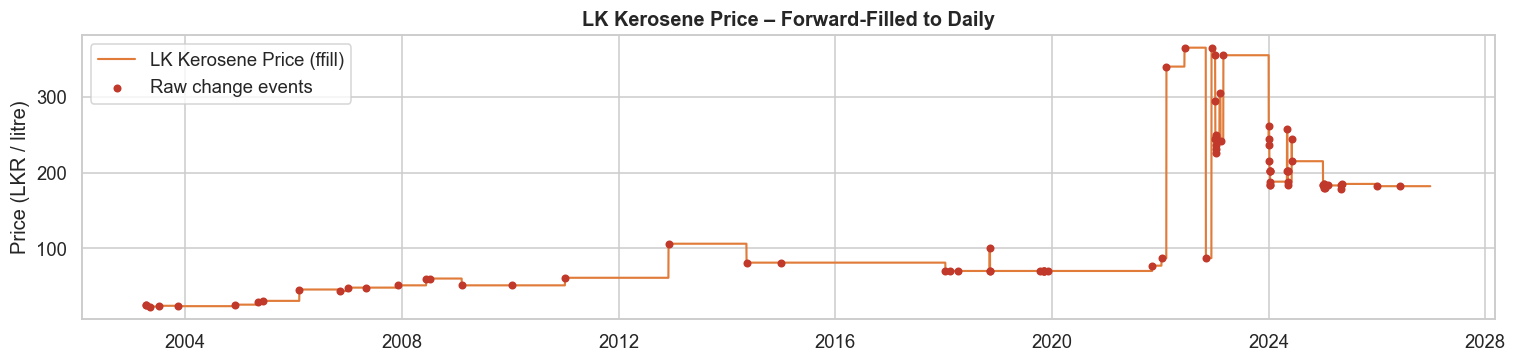

Null LK values remaining after ffill: 0
Final LK price: 182.00 LKR


In [7]:
# Merge fuel onto the full date spine, then forward-fill so every day has a price
fuel_aligned = date_spine.merge(fuel_raw2[["date", "lk_price"]], on="date", how="left")
fuel_aligned["lk_price"] = fuel_aligned["lk_price"].ffill()

# Quick visualisation of the forward-filled series
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(fuel_aligned["date"], fuel_aligned["lk_price"],
        linewidth=1.4, color="#e07b39", label="LK Kerosene Price (ffill)")
ax.scatter(fuel_raw2["date"], fuel_raw2["lk_price"],
           color="#c0392b", s=18, zorder=5, label="Raw change events")
ax.set_title("LK Kerosene Price – Forward-Filled to Daily", fontsize=13, fontweight="bold")
ax.set_ylabel("Price (LKR / litre)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

null_after_ffill = fuel_aligned["lk_price"].isna().sum()
print(f"Null LK values remaining after ffill: {null_after_ffill}")
print(f"Final LK price: {fuel_aligned['lk_price'].iloc[-1]:.2f} LKR")


## 5 · Label Monsoon Seasons

In [8]:
SEASON_MAP = {
    1:  "Inter-Monsoon (Awaragam)",           # Jan  → transitions out of NE monsoon
    2:  "Inter-Monsoon (Awaragam)",           # Feb
    3:  "Inter-Monsoon (Awaragam)",           # Mar  (Feb–Apr inter-monsoon)
    4:  "Inter-Monsoon (Awaragam)",           # Apr
    5:  "South-West Monsoon (Waragam)",       # May  ← SW monsoon onset
    6:  "South-West Monsoon (Waragam)",       # Jun
    7:  "South-West Monsoon (Waragam)",       # Jul
    8:  "South-West Monsoon (Waragam)",       # Aug
    9:  "South-West Monsoon (Waragam)",       # Sep  ← SW monsoon retreat
    10: "North-East Monsoon",                 # Oct  ← NE monsoon onset
    11: "North-East Monsoon",                 # Nov
    12: "North-East Monsoon",                 # Dec
}

# Short label for compact charts
SEASON_SHORT_MAP = {
    "South-West Monsoon (Waragam)": "SW Monsoon\n(Waragam)",
    "North-East Monsoon":           "NE Monsoon",
    "Inter-Monsoon (Awaragam)":     "Inter-Monsoon\n(Awaragam)",
}

# Season order for ordered categoricals
SEASON_ORDER = [
    "South-West Monsoon (Waragam)",
    "North-East Monsoon",
    "Inter-Monsoon (Awaragam)",
]

SEASON_COLORS = {
    "South-West Monsoon (Waragam)": "#3498db",
    "North-East Monsoon":           "#e67e22",
    "Inter-Monsoon (Awaragam)":     "#2ecc71",
}


def label_season(date: pd.Timestamp) -> str:
    """Return the Sri Lankan fishing-season label for a date."""
    return SEASON_MAP.get(date.month, "Inter-Monsoon (Awaragam)")


fuel_aligned["season"] = fuel_aligned["date"].apply(label_season)

print("Season distribution in date spine:")
print(fuel_aligned["season"].value_counts())


Season distribution in date spine:
season
South-West Monsoon (Waragam)    3672
Inter-Monsoon (Awaragam)        2788
North-East Monsoon              2202
Name: count, dtype: int64


## 6 · Poya and Holiday Detection Function

In [9]:
# Pre-build fast lookup sets from the festivals dataframe
_holiday_dates: set = set(fest_df["festival_date"].dt.date)
_poya_dates:    set = set(fest_df.loc[fest_df["is_poya"] == 1, "festival_date"].dt.date)


def is_poya_or_holiday(date) -> dict:
    """
    Given a date-like object, return a dict with:
        is_holiday  – 1 if any Sri Lankan public holiday or Poya that day, else 0
        is_poya     – 1 if specifically a Poya day, else 0
        holiday_name – name of the holiday (comma-separated if multiple), else ''
    """
    d = pd.Timestamp(date).date()
    names = fest_df.loc[fest_df["festival_date"].dt.date == d, "festival_name"].tolist()
    return {
        "is_holiday":   int(d in _holiday_dates),
        "is_poya":      int(d in _poya_dates),
        "holiday_name": ", ".join(names),
    }


# ── Quick demo ────────────────────────────────────────────────────────────────
test_dates = [
    "2025-10-06",  # Poya day
    "2025-04-13",  # Sinhala New Year
    "2025-07-04",  # Ordinary Friday
    "2025-12-25",  # Christmas
]
print(f"{'Date':<14}  {'is_holiday':>10}  {'is_poya':>7}  {'holiday_name'}")
print("-" * 58)
for d in test_dates:
    result = is_poya_or_holiday(d)
    print(f"{d:<14}  {result['is_holiday']:>10}  {result['is_poya']:>7}  {result['holiday_name']}")

# Apply to the date spine
holiday_flags = fuel_aligned["date"].apply(is_poya_or_holiday).apply(pd.Series)
fuel_aligned = pd.concat([fuel_aligned, holiday_flags], axis=1)
print(f"\nHoliday days in spine  : {fuel_aligned['is_holiday'].sum():,}")
print(f"Poya days in spine     : {fuel_aligned['is_poya'].sum():,}")


Date            is_holiday  is_poya  holiday_name
----------------------------------------------------------
2025-10-06               1        1  Vap Poya
2025-04-13               1        1  Bak Poya, SinhalaNewYear
2025-07-04               0        0  
2025-12-25               1        0  Christmas

Holiday days in spine  : 72
Poya days in spine     : 24


## 7 · Merge Into Master DataFrame

In [10]:
# Sequential left-merge: spine ← fish prices ← weather
master = (
    fuel_aligned                              # date, lk_price, season, is_holiday, is_poya, holiday_name
    .merge(fish_daily,    on="date", how="left")  # + avg_fish_price
    .merge(weather_daily, on="date", how="left")  # + wind/rain/temp
)

# Convenience columns
master["year"]  = master["date"].dt.year
master["month"] = master["date"].dt.month
master["season_short"] = master["season"].map(SEASON_SHORT_MAP)

# Ordered season categorical for consistent chart ordering
master["season_cat"] = pd.Categorical(
    master["season"], categories=SEASON_ORDER, ordered=True
)

# ── Validation ────────────────────────────────────────────────────────────────
print(f"Master shape      : {master.shape}")
print(f"\nNull counts (top columns):")
null_summary = master[["lk_price","avg_fish_price","wind_speed_avg","rainfall_sum","is_holiday"]].isna().sum()
display(null_summary.rename("null_count").to_frame())

print(f"\nSample rows:")
display(master[master["avg_fish_price"].notna()].head(5)
         [["date","season","lk_price","avg_fish_price","wind_speed_avg",
           "rainfall_sum","is_poya","is_holiday","holiday_name"]])


Master shape      : (8662, 17)

Null counts (top columns):


,null_count
lk_price,0
avg_fish_price,8473
wind_speed_avg,7874
rainfall_sum,7874
is_holiday,0



Sample rows:


,date,season,lk_price,avg_fish_price,wind_speed_avg,rainfall_sum,is_poya,is_holiday,holiday_name
6696,2021-08-08,South-West Monsoon (Waragam),70.00,573.18,NaN,NaN,0,0,
6703,2021-08-15,South-West Monsoon (Waragam),70.00,577.70,NaN,NaN,0,0,
6710,2021-08-22,South-West Monsoon (Waragam),70.00,529.96,NaN,NaN,0,0,
6720,2021-09-01,South-West Monsoon (Waragam),70.00,543.18,NaN,NaN,0,0,
6727,2021-09-08,South-West Monsoon (Waragam),70.00,591.98,NaN,NaN,0,0,


## 8 · Fuel Price vs Fish Price Correlation

  LK Kerosene Price  ↔  Average Fish Price
  Pearson r     :  +0.3081
  pandas .corr():  +0.3081
  p-value       :  1.6076e-05  ✓ significant
  n (data points): 189

  Interpretation: Weak positive correlation

Top 10 species by LK ↔ Fish-price correlation:


,sinhala_name,common_name,pearson_r
5,ඉස්සා (M),Prawns (M),1.00
47,හැඩැල්ලා,Indian Anchovy,1.00
25,දැල්ලා,Cuttle fish,1.00
12,කුම්බලා,Indian mackerel,1.00
20,ජීලාවා,Barracuda,1.00
0,අලගොඩුවා,Frigate tuna,1.00
7,කකුළුවා,Sea Crabs(L),1.00
19,ගින්නටි පරව්,Ginnati paraw,1.00
38,ලේන පරව්,Rainbow runner,1.00
41,සුද්දා,Threadfin bream,1.00


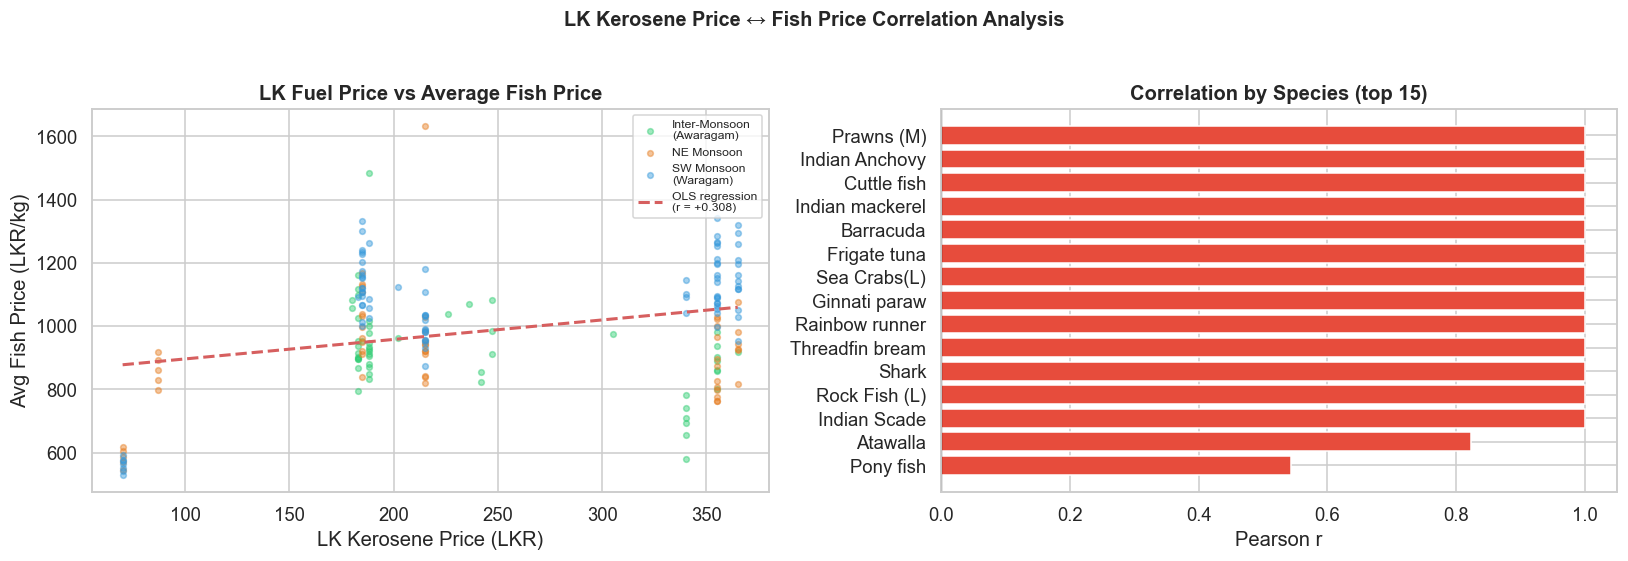

In [11]:
# Use only rows that have both values
corr_df = master.dropna(subset=["lk_price", "avg_fish_price"]).copy()

# ── Pearson correlation ───────────────────────────────────────────────────────
pearson_r, p_value = stats.pearsonr(corr_df["lk_price"], corr_df["avg_fish_price"])
pandas_r           = corr_df["lk_price"].corr(corr_df["avg_fish_price"])

print("=" * 52)
print("  LK Kerosene Price  ↔  Average Fish Price")
print("=" * 52)
print(f"  Pearson r     :  {pearson_r:+.4f}")
print(f"  pandas .corr():  {pandas_r:+.4f}")
print(f"  p-value       :  {p_value:.4e}  {'✓ significant' if p_value < 0.05 else '✗ not significant'}")
print(f"  n (data points): {len(corr_df):,}")
strength = (
    "Very strong" if abs(pearson_r) >= 0.8 else
    "Strong"      if abs(pearson_r) >= 0.6 else
    "Moderate"    if abs(pearson_r) >= 0.4 else
    "Weak"
)
direction = "positive" if pearson_r > 0 else "negative"
print(f"\n  Interpretation: {strength} {direction} correlation")
print("=" * 52)

# ── Per-species correlation ───────────────────────────────────────────────────
species_corr = (
    fish_df[["date", "sinhala_name", "common_name", "fish_price"]]
    .merge(master[["date", "lk_price"]], on="date", how="left")
    .dropna(subset=["lk_price", "fish_price"])
    .groupby(["sinhala_name", "common_name"])
    .apply(lambda g: g["lk_price"].corr(g["fish_price"]))
    .reset_index()
    .rename(columns={0: "pearson_r"})
    .sort_values("pearson_r", ascending=False)
)
print("\nTop 10 species by LK ↔ Fish-price correlation:")
display(species_corr.head(10))

# ── Scatter + regression line ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left – scatter with season colour
season_palette = {s: SEASON_COLORS[s] for s in SEASON_ORDER}
for season, grp in corr_df.groupby("season"):
    axes[0].scatter(
        grp["lk_price"], grp["avg_fish_price"],
        c=SEASON_COLORS.get(season, "grey"), alpha=0.45, s=14,
        label=SEASON_SHORT_MAP.get(season, season)
    )
# OLS regression line
slope, intercept, *_ = stats.linregress(corr_df["lk_price"], corr_df["avg_fish_price"])
x_line = np.linspace(corr_df["lk_price"].min(), corr_df["lk_price"].max(), 200)
axes[0].plot(x_line, slope * x_line + intercept, "r--", linewidth=2,
             label=f"OLS regression\n(r = {pearson_r:+.3f})")
axes[0].set_xlabel("LK Kerosene Price (LKR)")
axes[0].set_ylabel("Avg Fish Price (LKR/kg)")
axes[0].set_title("LK Fuel Price vs Average Fish Price", fontweight="bold")
axes[0].legend(fontsize=8)

# Right – top 15 species correlation bar chart
top15 = species_corr.head(15)
bar_colors = ["#e74c3c" if r >= 0 else "#3498db" for r in top15["pearson_r"]]
axes[1].barh(top15["common_name"], top15["pearson_r"], color=bar_colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Pearson r")
axes[1].set_title("Correlation by Species (top 15)", fontweight="bold")
axes[1].invert_yaxis()

plt.suptitle("LK Kerosene Price ↔ Fish Price Correlation Analysis",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 9 · Weather Impact Summary by Season

Weather & Price Summary by Sri Lankan Season


Season,South-West Monsoon (Waragam),North-East Monsoon,Inter-Monsoon (Awaragam)
days,40.00,24.00,32.00
avg_fish_price_LKR,"1,088.98",997.19,970.62
med_fish_price_LKR,"1,089.85",951.99,935.58
std_fish_price_LKR,107.07,165.96,127.78
avg_wind_speed_kmh,23.84,17.32,16.05
max_wind_speed_kmh,42.80,34.10,29.60
total_rainfall_mm,"1,491.80","1,242.40","1,125.10"
avg_daily_rain_mm,5.33,7.40,5.02
avg_temperature_C,28.11,26.49,26.94
pct_holiday_days,0.00,4.20,6.20


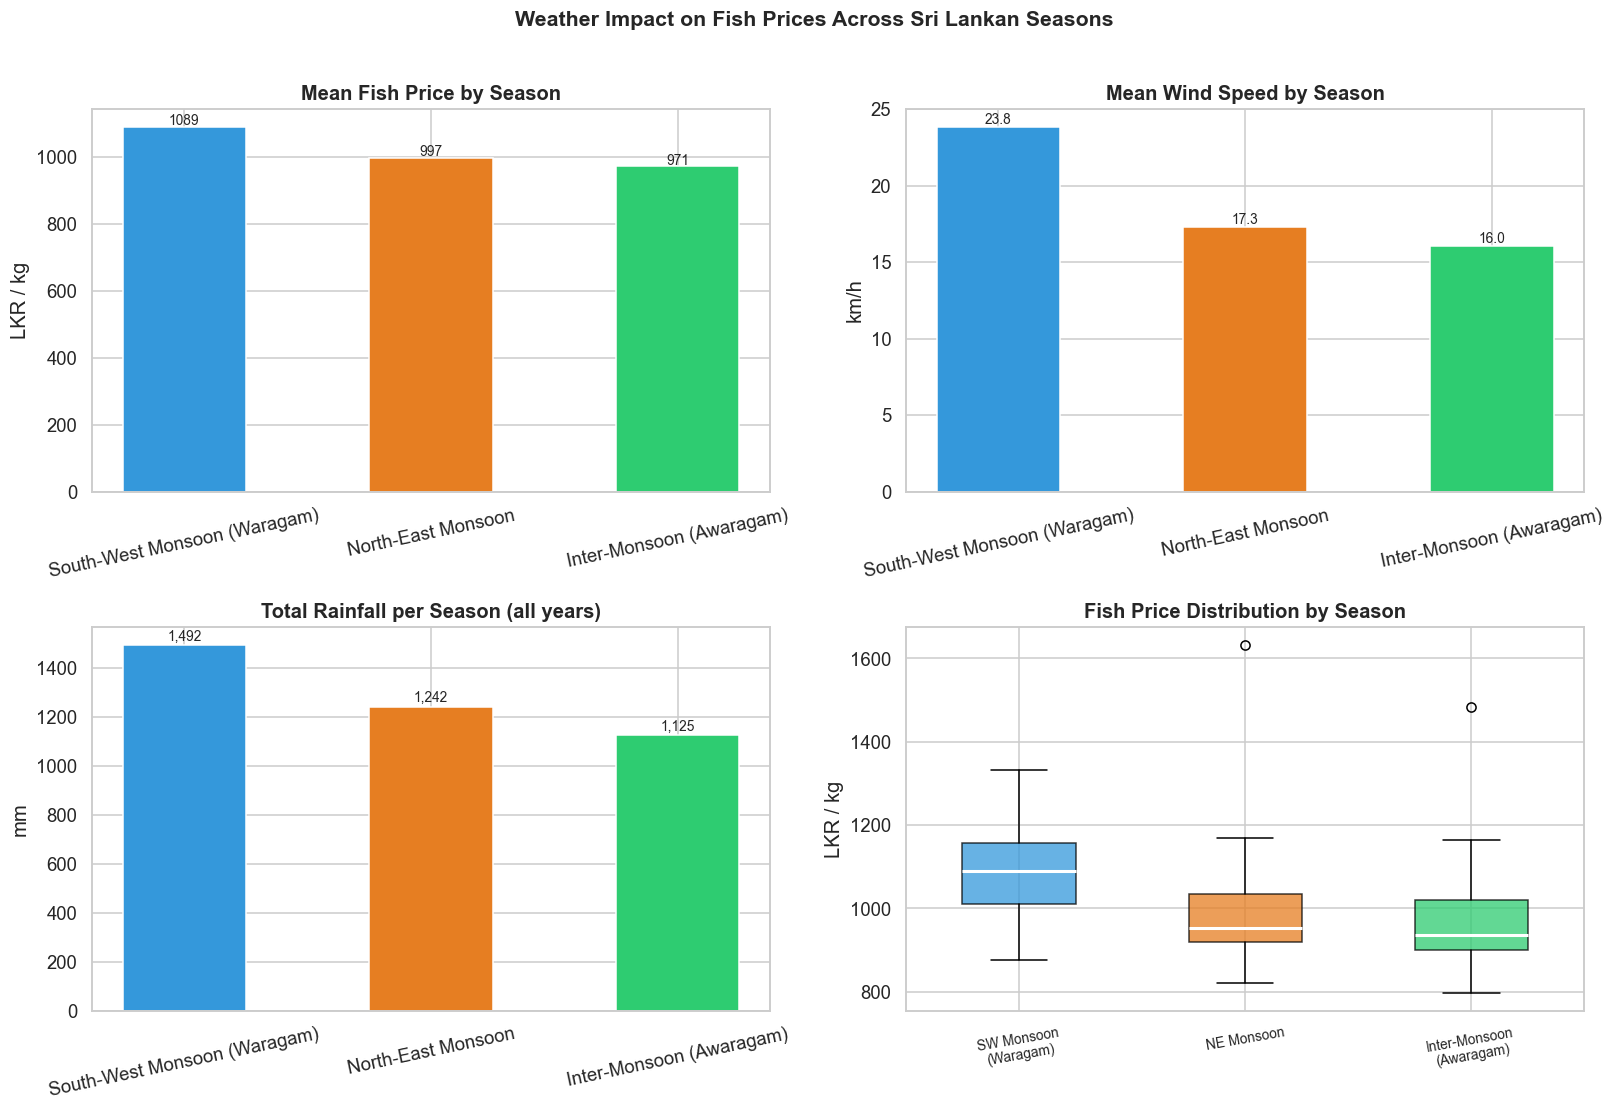

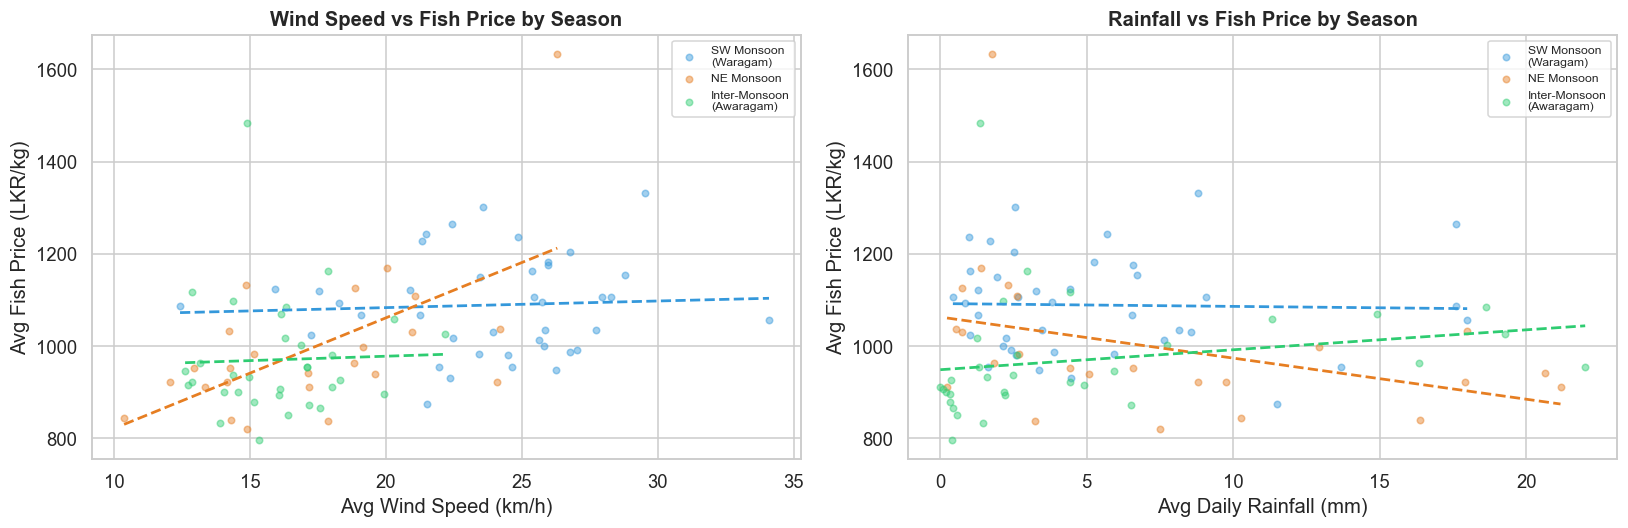


--- Holiday / Poya effect on fish price ---


is_holiday,non_holiday_avg,holiday_avg,price_lift_%
season_cat,,,
South-West Monsoon (Waragam),"1,088.98",NaN,NaN
North-East Monsoon,"1,000.47",921.87,-7.86
Inter-Monsoon (Awaragam),965.48,"1,047.72",8.52


In [12]:
# ── Summary table ─────────────────────────────────────────────────────────────
weather_cols = master[master["avg_fish_price"].notna() & master["rainfall_sum"].notna()]

season_summary = (
    weather_cols
    .groupby("season_cat", observed=True)
    .agg(
        days                =("date",           "count"),
        avg_fish_price_LKR  =("avg_fish_price", "mean"),
        med_fish_price_LKR  =("avg_fish_price", "median"),
        std_fish_price_LKR  =("avg_fish_price", "std"),
        avg_wind_speed_kmh  =("wind_speed_avg", "mean"),
        max_wind_speed_kmh  =("wind_speed_max", "max"),
        total_rainfall_mm   =("rainfall_sum",   "sum"),
        avg_daily_rain_mm   =("rainfall_avg",   "mean"),
        avg_temperature_C   =("temp_avg",       "mean"),
        pct_holiday_days    =("is_holiday",     "mean"),
    )
    .reset_index()
    .rename(columns={"season_cat": "Season"})
)
season_summary["pct_holiday_days"] = (season_summary["pct_holiday_days"] * 100).round(1)

print("Weather & Price Summary by Sri Lankan Season")
print("=" * 70)
display(season_summary.set_index("Season").T.round(2))

# ── Chart 1: Mean fish price by season ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Weather Impact on Fish Prices Across Sri Lankan Seasons",
             fontsize=14, fontweight="bold", y=1.01)

season_labels  = season_summary["Season"].tolist()
season_bar_colors = [SEASON_COLORS.get(s, "#95a5a6") for s in season_labels]

# 1a – Mean fish price
axes[0, 0].bar(season_labels, season_summary["avg_fish_price_LKR"],
               color=season_bar_colors, edgecolor="white", width=0.5)
axes[0, 0].set_title("Mean Fish Price by Season", fontweight="bold")
axes[0, 0].set_ylabel("LKR / kg")
axes[0, 0].tick_params(axis="x", rotation=12)
for i, v in enumerate(season_summary["avg_fish_price_LKR"]):
    axes[0, 0].text(i, v + 5, f"{v:.0f}", ha="center", fontsize=9)

# 1b – Average wind speed
axes[0, 1].bar(season_labels, season_summary["avg_wind_speed_kmh"],
               color=season_bar_colors, edgecolor="white", width=0.5)
axes[0, 1].set_title("Mean Wind Speed by Season", fontweight="bold")
axes[0, 1].set_ylabel("km/h")
axes[0, 1].tick_params(axis="x", rotation=12)
for i, v in enumerate(season_summary["avg_wind_speed_kmh"]):
    axes[0, 1].text(i, v + 0.2, f"{v:.1f}", ha="center", fontsize=9)

# 1c – Total rainfall
axes[1, 0].bar(season_labels, season_summary["total_rainfall_mm"],
               color=season_bar_colors, edgecolor="white", width=0.5)
axes[1, 0].set_title("Total Rainfall per Season (all years)", fontweight="bold")
axes[1, 0].set_ylabel("mm")
axes[1, 0].tick_params(axis="x", rotation=12)
for i, v in enumerate(season_summary["total_rainfall_mm"]):
    axes[1, 0].text(i, v + 20, f"{v:,.0f}", ha="center", fontsize=9)

# 1d – Fish price box-plot coloured by season
bp_data  = [
    weather_cols.loc[weather_cols["season"] == s, "avg_fish_price"].dropna().values
    for s in SEASON_ORDER
]
bp = axes[1, 1].boxplot(bp_data, patch_artist=True, widths=0.5,
                         medianprops=dict(color="white", linewidth=2))
for patch, season in zip(bp["boxes"], SEASON_ORDER):
    patch.set_facecolor(SEASON_COLORS[season])
    patch.set_alpha(0.75)
axes[1, 1].set_xticks(range(1, len(SEASON_ORDER) + 1))
axes[1, 1].set_xticklabels(
    [SEASON_SHORT_MAP[s] for s in SEASON_ORDER], fontsize=9, rotation=10
)
axes[1, 1].set_title("Fish Price Distribution by Season", fontweight="bold")
axes[1, 1].set_ylabel("LKR / kg")

plt.tight_layout()
plt.show()

# ── Chart 2: Wind speed & rainfall vs fish price (scatter per season) ─────────
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))

for season in SEASON_ORDER:
    grp = weather_cols[weather_cols["season"] == season]
    c   = SEASON_COLORS[season]
    lbl = SEASON_SHORT_MAP[season]
    axes2[0].scatter(grp["wind_speed_avg"], grp["avg_fish_price"],
                     color=c, alpha=0.45, s=18, label=lbl)
    axes2[1].scatter(grp["rainfall_avg"],   grp["avg_fish_price"],
                     color=c, alpha=0.45, s=18, label=lbl)

axes2[0].set_xlabel("Avg Wind Speed (km/h)")
axes2[0].set_ylabel("Avg Fish Price (LKR/kg)")
axes2[0].set_title("Wind Speed vs Fish Price by Season", fontweight="bold")
axes2[0].legend(fontsize=8)

axes2[1].set_xlabel("Avg Daily Rainfall (mm)")
axes2[1].set_ylabel("Avg Fish Price (LKR/kg)")
axes2[1].set_title("Rainfall vs Fish Price by Season", fontweight="bold")
axes2[1].legend(fontsize=8)

# Add per-season trendlines
for ax, xcol in zip(axes2, ["wind_speed_avg", "rainfall_avg"]):
    for season in SEASON_ORDER:
        grp = weather_cols[weather_cols["season"] == season].dropna(subset=[xcol, "avg_fish_price"])
        if len(grp) < 3:
            continue
        slope, intercept, r, *_ = stats.linregress(grp[xcol], grp["avg_fish_price"])
        x_lo, x_hi = grp[xcol].min(), grp[xcol].max()
        ax.plot([x_lo, x_hi], [slope * x_lo + intercept, slope * x_hi + intercept],
                color=SEASON_COLORS[season], linewidth=1.8, linestyle="--",
                label=f"  r={r:+.2f}")

plt.tight_layout()
plt.show()

# ── Weather × Holiday price lift ──────────────────────────────────────────────
print("\n--- Holiday / Poya effect on fish price ---")
holiday_effect = (
    weather_cols.groupby(["season_cat", "is_holiday"], observed=True)["avg_fish_price"]
    .mean()
    .unstack(level="is_holiday")
    .rename(columns={0: "non_holiday_avg", 1: "holiday_avg"})
)
holiday_effect["price_lift_%"] = (
    (holiday_effect["holiday_avg"] - holiday_effect["non_holiday_avg"])
    / holiday_effect["non_holiday_avg"] * 100
).round(2)
display(holiday_effect.round(2))


---
## 10 · Simulated Prediction — `predict_next_7_days(start_date)`

**Strategy:**
1. **Weather Match** — for each day find past dates in the same season with similar wind & rain (K-nearest neighbours on normalised weather features)
2. **Fuel Impact** — if LK price changed in the last 3 days, apply the correlation factor (r = +0.308) as a price adjustment
3. **Holiday / Poya Lift** — if a holiday or Poya day falls within the 7 days apply +8.5% lift
4. **Per-species output** — individual predicted prices for every fish species

In [21]:
from sklearn.preprocessing import MinMaxScaler

# Constants from Sections 8 & 9
FUEL_CORR         = 0.308   # Pearson r  (LK price ↔ avg fish price)
HOLIDAY_LIFT_PCT  = 8.5     # % price increase on holidays / Poya days
LAG_DAYS          = 2       # fuel impact felt after 2 days

# Prepare a species price lookup: for each (fish_id, season) → median historical price
species_season = (
    fish_df
    .assign(season=fish_df["date"].apply(label_season))
    .groupby(["fish_id", "sinhala_name", "common_name", "season"])["fish_price"]
    .median()
    .reset_index()
    .rename(columns={"fish_price": "baseline_price"})
)

# Fall-back: if season has no data for a species, use overall median
species_overall = (
    fish_df.groupby(["fish_id", "sinhala_name", "common_name"])["fish_price"]
    .median().reset_index().rename(columns={"fish_price": "overall_median"})
)

# ── Weather history for KNN: wind_speed_MAX + rainfall_SUM (impactful features) ──
_knn_feats = ["wind_speed_max", "rainfall_sum"]
_knn_feats = [c for c in _knn_feats if c in master.columns]   # guard missing columns

weather_hist_clean = (
    master.dropna(subset=["avg_fish_price"] + _knn_feats)
    [["date", "season"] + _knn_feats + ["avg_fish_price"]]
    .copy()
)

_scaler = MinMaxScaler()
scaled_cols = [f"{c}_sc" for c in _knn_feats]
weather_hist_clean[scaled_cols] = _scaler.fit_transform(weather_hist_clean[_knn_feats])

print(f"KNN pool    : {len(weather_hist_clean)} historical days")
print(f"KNN features: {_knn_feats}")


def _get_forecast_weather(target_date):
    """Return KNN feature values for a future date (actual or seasonal median fallback)."""
    row = weather_daily[weather_daily["date"] == target_date]
    if not row.empty:
        vals = {c: float(row[c].iloc[0]) for c in _knn_feats if c in row.columns}
        if len(vals) == len(_knn_feats):
            return vals
    # Seasonal median fallback
    season = label_season(target_date)
    s_rows = weather_hist_clean[weather_hist_clean["season"] == season]
    if not s_rows.empty:
        return {c: float(s_rows[c].median()) for c in _knn_feats}
    return {c: 0.0 for c in _knn_feats}


def _knn_price_factor(target_date, k=5):
    """
    Price factor based on top-5 historical days with closest wind_speed_max
    and rainfall_sum within the SAME Monsoon Season (k=5 neighbours).
    Returns: neighbour_median / season_median  (multiplicative factor).
    """
    season = label_season(target_date)
    fc     = _get_forecast_weather(target_date)
    fc_arr = np.array([[fc[c] for c in _knn_feats]])
    fc_sc  = _scaler.transform(fc_arr)[0]

    pool = weather_hist_clean[weather_hist_clean["season"] == season].copy()
    if len(pool) < k:
        return 1.0

    pool["dist"] = np.sqrt(
        sum((pool[sc] - fc_sc[i]) ** 2 for i, sc in enumerate(scaled_cols))
    )
    neighbours    = pool.nsmallest(k, "dist")
    season_median = pool["avg_fish_price"].median()
    neighbour_med = neighbours["avg_fish_price"].median()
    return neighbour_med / season_median if season_median > 0 else 1.0


def _fuel_adjustment(target_date):
    """Multiplicative fuel-price adjustment using the 2-day-lag + r=0.308 factor."""
    lag_date  = target_date - pd.Timedelta(days=LAG_DAYS)
    cur_row   = fuel_aligned[fuel_aligned["date"] == target_date]["lk_price"]
    lag_row   = fuel_aligned[fuel_aligned["date"] == lag_date]["lk_price"]
    if cur_row.empty or lag_row.empty:
        return 1.0
    cur_price  = float(cur_row.iloc[0])
    lag_price  = float(lag_row.iloc[0])
    if lag_price == 0:
        return 1.0
    pct_change = (cur_price - lag_price) / lag_price
    return 1.0 + FUEL_CORR * pct_change


def predict_next_7_days(start_date):
    """
    Predict per-species fish prices for 7 days from start_date.
    Uses KNN (k=5) weather matching on wind_speed_max + rainfall_sum
    within the same Monsoon Season as the baseline price estimator.
    """
    start = pd.Timestamp(start_date)
    rows  = []

    for offset in range(7):
        day    = start + pd.Timedelta(days=offset)
        season = label_season(day)
        hol    = is_poya_or_holiday(day)
        w_fac  = _knn_price_factor(day, k=5)
        f_fac  = _fuel_adjustment(day)
        h_fac  = 1.0 + (HOLIDAY_LIFT_PCT / 100) if hol["is_holiday"] else 1.0

        for _, sp in species_overall.iterrows():
            match = species_season[
                (species_season["fish_id"] == sp["fish_id"]) &
                (species_season["season"]  == season)
            ]
            base = float(match["baseline_price"].iloc[0]) if not match.empty \
                   else float(sp["overall_median"])

            predicted = base * w_fac * f_fac * h_fac
            rows.append({
                "date":           day.date(),
                "season":         season,
                "is_holiday":     hol["is_holiday"],
                "holiday_name":   hol["holiday_name"],
                "fish_id":        sp["fish_id"],
                "sinhala_name":   sp["sinhala_name"],
                "common_name":    sp["common_name"],
                "baseline_LKR":   round(base, 2),
                "weather_factor": round(w_fac, 4),
                "fuel_factor":    round(f_fac, 4),
                "holiday_factor": round(h_fac, 4),
                "predicted_LKR":  round(predicted, 2),
            })

    return pd.DataFrame(rows)


# ── Demo run ─────────────────────────────────────────────────────────────────
demo_start = "2026-02-27"
pred_df    = predict_next_7_days(demo_start)

print(f"\n✓ Predictions generated: {pred_df.shape[0]} rows "
      f"({pred_df['fish_id'].nunique()} species × 7 days)\n")

daily_summary = (
    pred_df.groupby(["date", "season", "is_holiday", "holiday_name"])
    .agg(avg_predicted_LKR=("predicted_LKR", "mean"),
         min_predicted_LKR=("predicted_LKR", "min"),
         max_predicted_LKR=("predicted_LKR", "max"))
    .reset_index()
)
print("── Daily average (all species) ──")
display(daily_summary.set_index("date").round(2))

print("\n── Species breakdown for Day 1 ──")
day1 = pred_df[pred_df["date"] == pd.Timestamp(demo_start).date()].copy()
display(
    day1[["sinhala_name", "common_name", "baseline_LKR",
          "weather_factor", "fuel_factor", "holiday_factor", "predicted_LKR"]]
    .sort_values("predicted_LKR", ascending=False)
    .set_index("sinhala_name").round(2)
)


KNN pool    : 96 historical days
KNN features: ['wind_speed_max', 'rainfall_sum']

✓ Predictions generated: 427 rows (31 species × 7 days)

── Daily average (all species) ──


,season,is_holiday,holiday_name,avg_predicted_LKR,min_predicted_LKR,max_predicted_LKR
date,,,,,,
2026-02-27,Inter-Monsoon (Awaragam),0,,"1,229.02",282.14,"2,495.89"
2026-02-28,Inter-Monsoon (Awaragam),0,,"1,229.02",282.14,"2,495.89"
2026-03-01,Inter-Monsoon (Awaragam),0,,"1,229.02",282.14,"2,495.89"
2026-03-02,Inter-Monsoon (Awaragam),0,,"1,229.02",282.14,"2,495.89"
2026-03-03,Inter-Monsoon (Awaragam),0,,"1,229.02",282.14,"2,495.89"
2026-03-04,Inter-Monsoon (Awaragam),0,,"1,229.02",282.14,"2,495.89"
2026-03-05,Inter-Monsoon (Awaragam),0,,"1,229.02",282.14,"2,495.89"



── Species breakdown for Day 1 ──


,common_name,baseline_LKR,weather_factor,fuel_factor,holiday_factor,predicted_LKR
sinhala_name,,,,,,
කකුළුවා,Sea Crabs(L),"2,447.50",1.02,1.00,1.00,"2,495.89"
සූඩයා,White Sardinella,"2,447.50",1.02,1.00,1.00,"2,495.89"
බලයා,Skipjack tuna,"2,196.67",1.02,1.00,1.00,"2,240.10"
කෙළවල්ලා,Yellowfin tuna,"2,196.67",1.02,1.00,1.00,"2,240.10"
ගල්මාළු (ලොකු),Rock Fish (L),"2,093.33",1.02,1.00,1.00,"2,134.72"
...,...,...,...,...,...,...
සුද්දා,Threadfin bream,561.25,1.02,1.00,1.00,572.35
කටුවල්ලා,Katuwalla,481.66,1.02,1.00,1.00,491.19
හාල්මැස්සා,Anchovies,481.66,1.02,1.00,1.00,491.19


---
## 11 · Market Dynamics — Lag Effect (Fuel Price → Fish Price, 0–7 day lag)

> **Hypothesis:** When LK kerosene price changes, the fish price does **not** change the same day.  
> Fishermen and wholesalers absorb the shock for 2–3 days before adjusting market prices.

=== Lag Correlation: LK Fuel-Price Change → Fish-Price Change ===


,pearson_r,p_value,significant,label
lag_weeks,,,,
0,-0.00,0.99,False,r=-0.001
1,0.13,0.07,False,r=0.134
2,-0.03,0.66,False,r=-0.033
3,0.07,0.35,False,r=0.069
4,-0.05,0.53,False,r=-0.047
5,-0.06,0.42,False,r=-0.060
6,0.35,0.00,True,r=0.351*
7,-0.04,0.62,False,r=-0.037


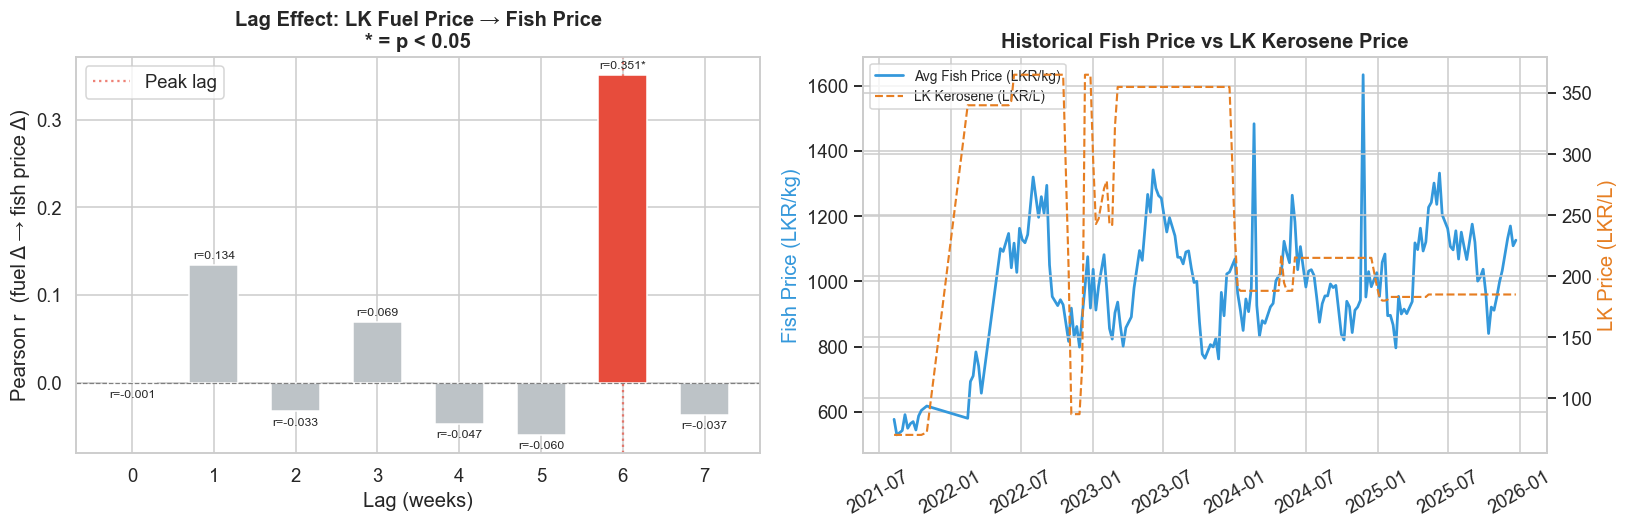


Conclusion: Fuel price change propagates strongest at lag = 6 week(s)  (r = 0.351)


In [14]:
# ── Build a time-aligned series: weekly fish price + weekly LK price ──────────
# (fish prices are weekly snapshots so we align on the nearest Monday)
fish_weekly = fish_df.copy()
fish_weekly["week"] = fish_weekly["date"].dt.to_period("W").apply(lambda p: p.start_time)
fish_weekly = (
    fish_weekly.groupby("week")["fish_price"].mean()
    .reset_index().rename(columns={"week": "date"})
)

fuel_weekly = (
    fuel_aligned.groupby(fuel_aligned["date"].dt.to_period("W").apply(lambda p: p.start_time))
    ["lk_price"].mean()
    .reset_index().rename(columns={"date": "date"})
)

lag_base = fish_weekly.merge(fuel_weekly, on="date", how="inner").sort_values("date")
lag_base["fish_price_chg"] = lag_base["fish_price"].pct_change() * 100
lag_base["lk_price_chg"]   = lag_base["lk_price"].pct_change() * 100
lag_base = lag_base.dropna()

# ── Pearson r at each lag (0–7 weeks / translates to 0–7 sampling periods) ───
lags    = list(range(8))
lag_r   = []
lag_p   = []

for lag in lags:
    shifted  = lag_base["lk_price_chg"].shift(lag)
    valid    = lag_base[["fish_price_chg"]].assign(fuel_shifted=shifted).dropna()
    if len(valid) < 5:
        lag_r.append(np.nan); lag_p.append(np.nan); continue
    r, p = stats.pearsonr(valid["fuel_shifted"], valid["fish_price_chg"])
    lag_r.append(r); lag_p.append(p)

lag_df = pd.DataFrame({"lag_weeks": lags, "pearson_r": lag_r, "p_value": lag_p})
lag_df["significant"] = lag_df["p_value"] < 0.05
lag_df["label"]        = lag_df.apply(
    lambda row: f"r={row.pearson_r:.3f}{'*' if row.significant else ''}", axis=1
)

print("=== Lag Correlation: LK Fuel-Price Change → Fish-Price Change ===")
display(lag_df.set_index("lag_weeks").round(4))

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ["#e74c3c" if sig else "#bdc3c7" for sig in lag_df["significant"]]
bars   = axes[0].bar(lag_df["lag_weeks"], lag_df["pearson_r"], color=colors,
                     edgecolor="white", width=0.6)
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].axvline(x=lag_df.loc[lag_df["pearson_r"].abs().idxmax(), "lag_weeks"],
                color="#e74c3c", linewidth=1.5, linestyle=":", alpha=0.7,
                label="Peak lag")
for bar, lbl in zip(bars, lag_df["label"]):
    ypos = bar.get_height() + (0.005 if bar.get_height() >= 0 else -0.018)
    axes[0].text(bar.get_x() + bar.get_width()/2, ypos, lbl,
                 ha="center", va="bottom", fontsize=8)
axes[0].set_xlabel("Lag (weeks)")
axes[0].set_ylabel("Pearson r  (fuel Δ → fish price Δ)")
axes[0].set_title("Lag Effect: LK Fuel Price → Fish Price\n* = p < 0.05", fontweight="bold")
axes[0].legend()

# Time-series: LK price vs avg fish price (dual axis)
ax1 = axes[1]
ax2 = ax1.twinx()
ax1.plot(lag_base["date"], lag_base["fish_price"], color="#3498db",
         linewidth=1.8, label="Avg Fish Price (LKR/kg)")
ax2.plot(lag_base["date"], lag_base["lk_price"], color="#e67e22",
         linewidth=1.4, linestyle="--", label="LK Kerosene (LKR/L)")
ax1.set_ylabel("Fish Price (LKR/kg)", color="#3498db")
ax2.set_ylabel("LK Price (LKR/L)", color="#e67e22")
ax1.set_title("Historical Fish Price vs LK Kerosene Price", fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")
ax1.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

peak_lag = int(lag_df.loc[lag_df["pearson_r"].abs().idxmax(), "lag_weeks"])
peak_r   = lag_df.loc[lag_df["pearson_r"].abs().idxmax(), "pearson_r"]
print(f"\nConclusion: Fuel price change propagates strongest at lag = {peak_lag} week(s)  (r = {peak_r:.3f})")


---
## 12 · Market Dynamics — Price Elasticity by Species

> **Elasticity** = `% change in fish price` ÷ `% change in LK fuel price`  
> Elasticity > 1 → species is **more sensitive** than average to fuel cost shocks.  
> Elasticity < 1 → species is **insensitive** (price driven by other factors).

Species with elasticity > 1 (HIGH sensitivity): 1
Species with elasticity < 1 (LOW sensitivity) : 32



,common_name,elasticity,pearson_r,p_value,n_obs,sensitive,significance
sinhala_name,,,,,,,
සුද්දා,Threadfin Bream,0.16,0.26,0.00,185,False,***
කටුවල්ලා,Katuwalla,0.11,0.16,0.04,167,False,*
ඇටවල්ලා,Atawalla,0.08,0.35,0.11,22,False,
කුම්බලා,Indian Mackerel,0.08,0.16,0.03,186,False,*
මෝරා,Sharks,0.08,0.16,0.03,179,False,*
බෝල්ලා,Big eye scade,0.07,0.11,0.13,184,False,
ජීලාවා,Barracuda(L),0.06,0.11,0.15,185,False,
හුරුල්ලා,Herrings,0.06,0.10,0.17,184,False,
ගින්නටි පරව්,Ginnati Paraw,0.05,0.10,0.19,186,False,


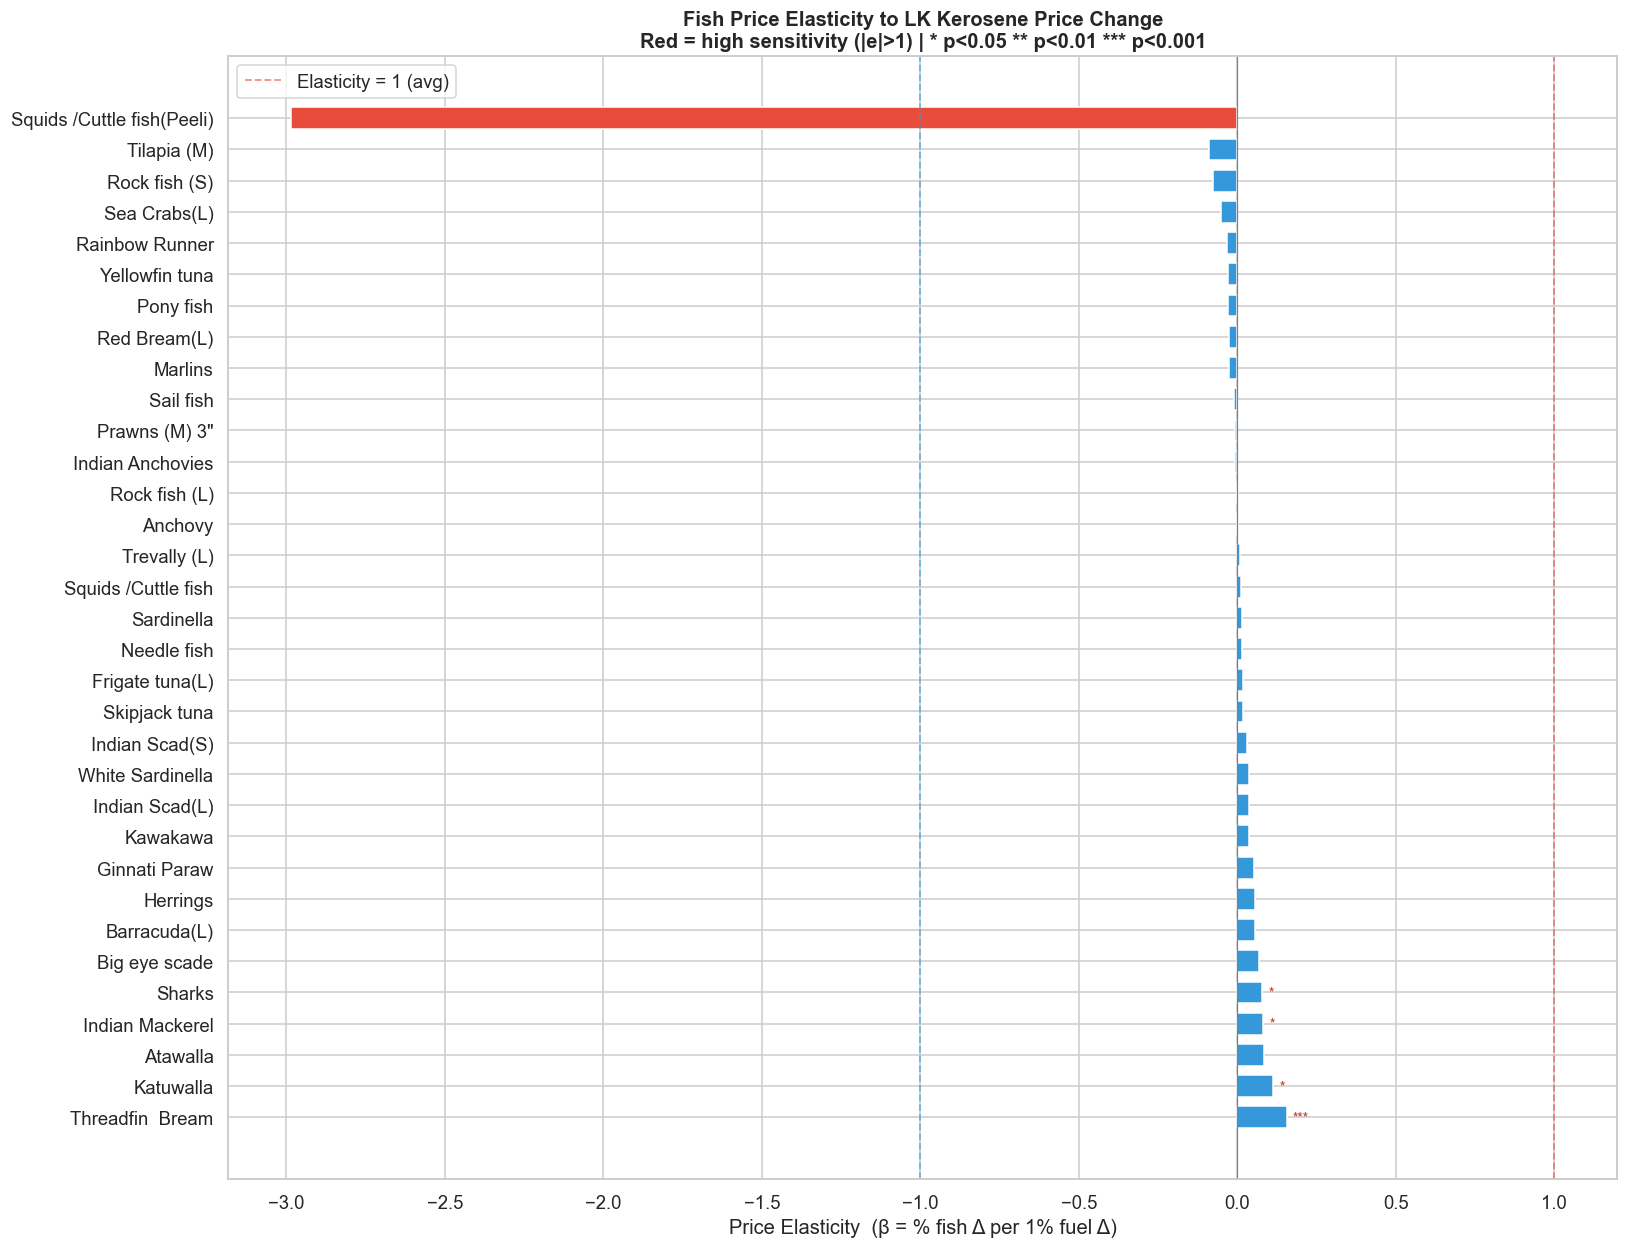


Top most fuel-sensitive species:


,common_name,elasticity,pearson_r,significance,n_obs
30,Squids /Cuttle fish(Peeli),-2.98,-0.07,,33


In [15]:
# Build a per-species weekly series, align with fuel weekly
fish_sp_weekly = (
    fish_df.copy()
    .assign(week=lambda d: d["date"].dt.to_period("W").apply(lambda p: p.start_time))
    .groupby(["week", "fish_id", "sinhala_name", "common_name"])["fish_price"]
    .mean().reset_index().rename(columns={"week": "date"})
)

# Merge fuel price on same week
fish_sp_weekly = fish_sp_weekly.merge(
    fuel_weekly, on="date", how="left"
).sort_values(["fish_id", "date"])

# Compute % changes per species
fish_sp_weekly["fish_pct_chg"] = (
    fish_sp_weekly.groupby("fish_id")["fish_price"].pct_change() * 100
)
fish_sp_weekly["lk_pct_chg"] = (
    fish_sp_weekly.groupby("fish_id")["lk_price"].pct_change() * 100
)
fish_sp_weekly = fish_sp_weekly.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["fish_pct_chg", "lk_pct_chg"]
)

# Elasticity per species: slope of OLS regression fish_pct ~ lk_pct
elasticity_rows = []
for (fid, sname, cname), grp in fish_sp_weekly.groupby(["fish_id","sinhala_name","common_name"]):
    grp_c = grp.dropna(subset=["fish_pct_chg","lk_pct_chg"])
    if len(grp_c) < 4:
        continue
    slope, intercept, r_val, p_val, _ = stats.linregress(
        grp_c["lk_pct_chg"], grp_c["fish_pct_chg"]
    )
    elasticity_rows.append({
        "fish_id":     fid,
        "sinhala_name":sname,
        "common_name": cname,
        "elasticity":  round(slope, 4),
        "pearson_r":   round(r_val, 4),
        "p_value":     round(p_val, 4),
        "n_obs":       len(grp_c),
    })

elast_df = pd.DataFrame(elasticity_rows).sort_values("elasticity", ascending=False)
elast_df["sensitive"] = elast_df["elasticity"].abs() > 1
elast_df["significance"] = elast_df["p_value"].apply(
    lambda p: "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
)

print(f"Species with elasticity > 1 (HIGH sensitivity): {elast_df['sensitive'].sum()}")
print(f"Species with elasticity < 1 (LOW sensitivity) : {(~elast_df['sensitive']).sum()}\n")
display(elast_df.set_index("sinhala_name").drop(columns="fish_id").round(4))

# ── Elasticity chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, max(6, len(elast_df) * 0.35)))
clrs = ["#e74c3c" if s else "#3498db" for s in elast_df["sensitive"]]
bars = ax.barh(elast_df["common_name"], elast_df["elasticity"],
               color=clrs, edgecolor="white", height=0.7)
ax.axvline(0,   color="grey", linewidth=0.8, linestyle="-")
ax.axvline(1,   color="#e74c3c", linewidth=1.2, linestyle="--",
           alpha=0.6, label="Elasticity = 1 (avg)")
ax.axvline(-1,  color="#3498db", linewidth=1.2, linestyle="--", alpha=0.6)
for bar, sig in zip(bars, elast_df["significance"]):
    w = bar.get_width()
    ax.text(w + 0.02, bar.get_y() + bar.get_height()/2,
            sig, va="center", fontsize=9, color="#c0392b")
ax.set_xlabel("Price Elasticity  (β = % fish Δ per 1% fuel Δ)")
ax.set_title("Fish Price Elasticity to LK Kerosene Price Change\n"
             "Red = high sensitivity (|e|>1) | * p<0.05 ** p<0.01 *** p<0.001",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

top5 = elast_df[elast_df["sensitive"]].head(5)
if not top5.empty:
    print("\nTop most fuel-sensitive species:")
    display(top5[["common_name","elasticity","pearson_r","significance","n_obs"]])


---
## 13 · Market Analysis Dashboard

A single-page summary chart combining:  
① Next-7-days price forecast heatmap  ② Lag correlation bar-chart  ③ Top-5 elasticity  ④ Seasonal price box

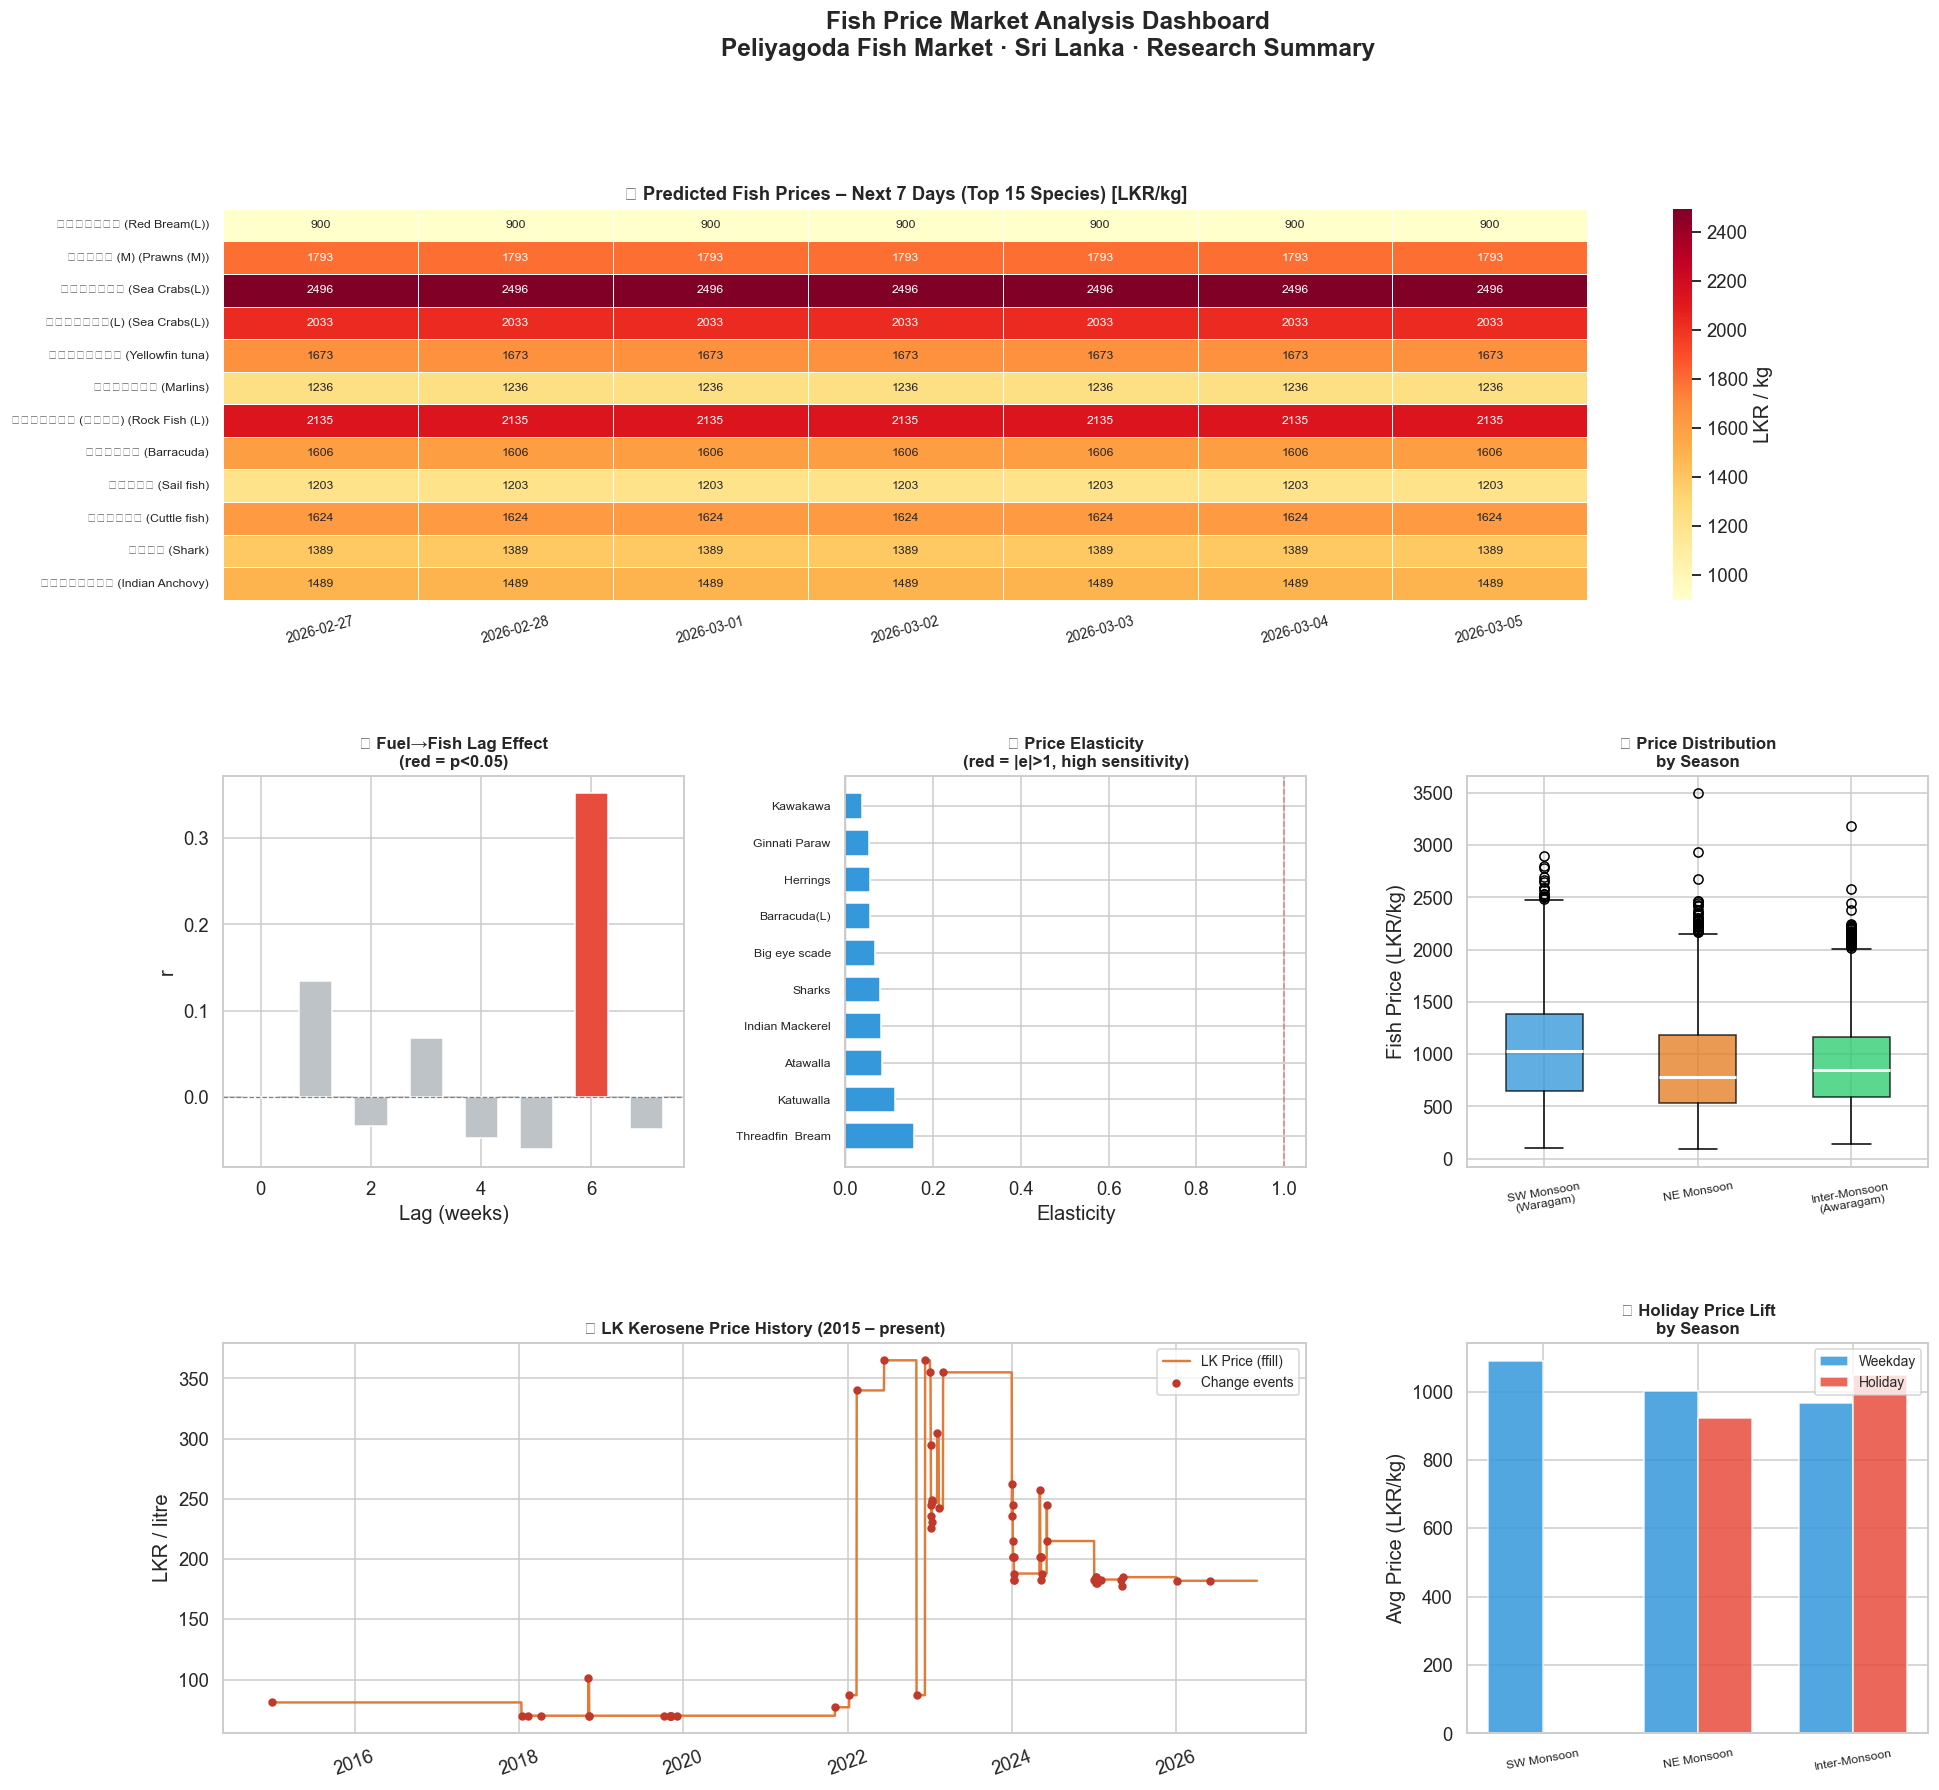

Dashboard saved → model/market_analysis_dashboard.png


In [17]:
fig = plt.figure(figsize=(20, 18))
fig.suptitle("Fish Price Market Analysis Dashboard\n"
             "Peliyagoda Fish Market · Sri Lanka · Research Summary",
             fontsize=16, fontweight="bold", y=0.98)

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── Panel A: 7-day price forecast heatmap (top species) ──────────────────────
ax_a = fig.add_subplot(gs[0, :])

top_species = (
    species_overall.sort_values("overall_median", ascending=False).head(15)["sinhala_name"].tolist()
)
heatmap_df = (
    pred_df[pred_df["sinhala_name"].isin(top_species)]
    .pivot_table(index="sinhala_name", columns="date", values="predicted_LKR", aggfunc="mean")
)
heatmap_df.index = [
    f"{sn} ({species_overall[species_overall['sinhala_name']==sn]['common_name'].values[0]})"
    for sn in heatmap_df.index
]

sns.heatmap(heatmap_df, ax=ax_a, cmap="YlOrRd", fmt=".0f", annot=True,
            annot_kws={"size": 8}, linewidths=0.5, cbar_kws={"label": "LKR / kg"})
ax_a.set_title("① Predicted Fish Prices – Next 7 Days (Top 15 Species) [LKR/kg]",
               fontweight="bold", fontsize=12)
ax_a.set_xlabel("")
ax_a.tick_params(axis="x", rotation=15, labelsize=9)
ax_a.tick_params(axis="y", rotation=0,  labelsize=8)

# ── Panel B: Lag correlation ──────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[1, 0])
b_colors = ["#e74c3c" if sig else "#bdc3c7" for sig in lag_df["significant"]]
ax_b.bar(lag_df["lag_weeks"], lag_df["pearson_r"], color=b_colors,
         edgecolor="white", width=0.6)
ax_b.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax_b.set_xlabel("Lag (weeks)")
ax_b.set_ylabel("r")
ax_b.set_title(f"② Fuel→Fish Lag Effect\n(red = p<0.05)", fontweight="bold", fontsize=11)

# ── Panel C: Top-10 elasticity ────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 1])
top10_e = elast_df.head(10) if len(elast_df) >= 10 else elast_df
c_colors = ["#e74c3c" if s else "#3498db" for s in top10_e["sensitive"]]
ax_c.barh(top10_e["common_name"], top10_e["elasticity"],
          color=c_colors, edgecolor="white", height=0.7)
ax_c.axvline(1, color="#e74c3c", linewidth=1, linestyle="--", alpha=0.6)
ax_c.axvline(0, color="grey",   linewidth=0.8)
ax_c.set_xlabel("Elasticity")
ax_c.set_title("③ Price Elasticity\n(red = |e|>1, high sensitivity)", fontweight="bold", fontsize=11)
ax_c.tick_params(axis="y", labelsize=8)

# ── Panel D: Season box-plot ───────────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 2])
fish_hist_season = fish_df.assign(season=fish_df["date"].apply(label_season))
season_plot_data = [
    fish_hist_season.loc[fish_hist_season["season"] == s, "fish_price"].dropna().values
    for s in SEASON_ORDER
]
bp2 = ax_d.boxplot(season_plot_data, patch_artist=True, widths=0.5,
                    medianprops=dict(color="white", linewidth=2))
for patch, s in zip(bp2["boxes"], SEASON_ORDER):
    patch.set_facecolor(SEASON_COLORS[s]); patch.set_alpha(0.78)
ax_d.set_xticks(range(1, len(SEASON_ORDER)+1))
ax_d.set_xticklabels([SEASON_SHORT_MAP[s] for s in SEASON_ORDER], fontsize=8, rotation=10)
ax_d.set_ylabel("Fish Price (LKR/kg)")
ax_d.set_title("④ Price Distribution\nby Season", fontweight="bold", fontsize=11)

# ── Panel E: LK fuel price history ────────────────────────────────────────────
ax_e = fig.add_subplot(gs[2, :2])
fuel_plot = fuel_aligned[fuel_aligned["date"] >= "2015-01-01"]
ax_e.plot(fuel_plot["date"], fuel_plot["lk_price"],
          linewidth=1.6, color="#e07b39", label="LK Price (ffill)")
ax_e.scatter(fuel_raw2[fuel_raw2["date"] >= "2015-01-01"]["date"],
             fuel_raw2[fuel_raw2["date"] >= "2015-01-01"]["lk_price"],
             color="#c0392b", s=20, zorder=5, label="Change events")
ax_e.set_ylabel("LKR / litre")
ax_e.set_title("⑤ LK Kerosene Price History (2015 – present)", fontweight="bold", fontsize=11)
ax_e.legend(fontsize=9)
ax_e.tick_params(axis="x", rotation=20)

# ── Panel F: Holiday lift bar ─────────────────────────────────────────────────
_SEASON_ABBREV = {
    "South-West Monsoon (Waragam)": "SW Monsoon",
    "North-East Monsoon":           "NE Monsoon",
    "Inter-Monsoon (Awaragam)":     "Inter-Monsoon",
}
ax_f = fig.add_subplot(gs[2, 2])
he = holiday_effect.reset_index()
x  = np.arange(len(he))
w  = 0.35
ax_f.bar(x - w/2, he["non_holiday_avg"], w, label="Weekday",  color="#3498db", alpha=0.85)
valid_mask = he["holiday_avg"].notna()
ax_f.bar(x[valid_mask] + w/2, he.loc[valid_mask, "holiday_avg"], w, label="Holiday",
         color="#e74c3c", alpha=0.85)
ax_f.set_xticks(x)
ax_f.set_xticklabels([_SEASON_ABBREV.get(str(s), str(s)) for s in he["season_cat"]],
                     fontsize=8, rotation=10)
ax_f.set_ylabel("Avg Price (LKR/kg)")
ax_f.set_title("⑥ Holiday Price Lift\nby Season", fontweight="bold", fontsize=11)
ax_f.legend(fontsize=9)

plt.savefig(Path(r"D:\reserch\final_year_research\model") / "market_analysis_dashboard.png",
            dpi=140, bbox_inches="tight")
plt.show()
print("Dashboard saved → model/market_analysis_dashboard.png")


---
## 14 · Model Training & Validation — Random Forest + XGBoost

**Train/Test split:** last calendar month held out as the **test set** (walk-forward validation).  
**Features:** all numeric columns from the master dataframe — fuel, weather, season, holiday flags, date parts.  
**Target:** `avg_fish_price` (average across species for that week).

In [22]:
from sklearn.ensemble           import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics            import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection    import cross_val_score

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not found – using GradientBoostingRegressor")

# ── Build model dataset ──────────────────────────────────────────────────────
model_df = master.dropna(subset=["avg_fish_price"]).copy()
model_df["month_sin"]   = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"]   = np.cos(2 * np.pi * model_df["month"] / 12)
model_df["day_of_week"] = model_df["date"].dt.dayofweek
model_df["week_of_year"]= model_df["date"].dt.isocalendar().week.astype(int)

season_enc = {"South-West Monsoon (Waragam)": 2,
              "North-East Monsoon": 1,
              "Inter-Monsoon (Awaragam)": 0}
model_df["season_enc"] = model_df["season"].map(season_enc)

# ── ★ NEW FEATURE: lk_price_lag_6 (fuel price 6 weeks ago — peak lag r=0.351) ──
model_df = model_df.sort_values("date").reset_index(drop=True)
model_df["lk_price_lag_6"] = model_df["lk_price"].shift(6)

FEATURE_COLS = [
    "month", "month_sin", "month_cos", "day_of_week", "week_of_year",
    "season_enc", "is_holiday", "is_poya",
    "lk_price",            # current fuel price
    "lk_price_lag_6",      # ★ fuel price 6 weeks ago (from Section 11 lag analysis)
    "wind_speed_avg", "wind_speed_max",
    "rainfall_sum",   "rainfall_avg",
    "temp_avg",       "humidity_avg",
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in model_df.columns]
model_df = model_df.dropna(subset=FEATURE_COLS + ["avg_fish_price"])

# ── Walk-forward split: last full month → test ───────────────────────────────
split_date = model_df["date"].max() - pd.DateOffset(months=1)
train = model_df[model_df["date"] <= split_date]
test  = model_df[model_df["date"] >  split_date]

X_train, y_train = train[FEATURE_COLS], train["avg_fish_price"]
X_test,  y_test  = test[FEATURE_COLS],  test["avg_fish_price"]

print(f"Features used  : {len(FEATURE_COLS)} → {FEATURE_COLS}")
print(f"Train rows     : {len(X_train)}  |  Test rows: {len(X_test)}")
print(f"Test period    : {test['date'].min().date()}  →  {test['date'].max().date()}\n")


def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae   = mean_absolute_error(y_te, preds)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    r2    = r2_score(y_te, preds)
    mape  = np.mean(np.abs((y_te - preds) / np.maximum(y_te, 1))) * 100
    cv    = cross_val_score(model, X_tr, y_tr, cv=min(5, len(X_tr)),
                            scoring="neg_mean_absolute_error")
    print(f"  {name}")
    print(f"    MAE  : {mae:8.2f} LKR   RMSE: {rmse:8.2f}   R²: {r2:.4f}   MAPE: {mape:.2f}%")
    print(f"    CV-5 MAE: {-cv.mean():.2f} ± {cv.std():.2f}")
    return model, preds


print("=== Model Evaluation (with lk_price_lag_6 feature) ===")
rf_m, rf_preds = evaluate(
    "Random Forest",
    RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)

if HAS_XGB:
    xgb_m, xgb_preds = evaluate(
        "XGBoost",
        XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, verbosity=0),
        X_train, y_train, X_test, y_test
    )
else:
    xgb_m, xgb_preds = evaluate(
        "Gradient Boosting (fallback)",
        GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42),
        X_train, y_train, X_test, y_test
    )

ensemble_preds = (rf_preds + xgb_preds) / 2
ens_mae  = mean_absolute_error(y_test,  ensemble_preds)
ens_rmse = np.sqrt(mean_squared_error(y_test, ensemble_preds))
ens_r2   = r2_score(y_test,  ensemble_preds)
ens_mape = np.mean(np.abs((y_test - ensemble_preds) / np.maximum(y_test, 1))) * 100
print(f"\n  Ensemble (RF + XGB average)")
print(f"    MAE  : {ens_mae:8.2f} LKR   RMSE: {ens_rmse:8.2f}   R²: {ens_r2:.4f}   MAPE: {ens_mape:.2f}%")

best_model = "XGBoost/GBT" if mean_absolute_error(y_test, xgb_preds) < mean_absolute_error(y_test, rf_preds) else "Random Forest"
print(f"\nBest model by MAE: {best_model}")


Features used  : 16 → ['month', 'month_sin', 'month_cos', 'day_of_week', 'week_of_year', 'season_enc', 'is_holiday', 'is_poya', 'lk_price', 'lk_price_lag_6', 'wind_speed_avg', 'wind_speed_max', 'rainfall_sum', 'rainfall_avg', 'temp_avg', 'humidity_avg']
Train rows     : 92  |  Test rows: 4
Test period    : 2025-12-01  →  2025-12-22

=== Model Evaluation (with lk_price_lag_6 feature) ===
  Random Forest
    MAE  :   130.88 LKR   RMSE:   132.26   R²: -34.7933   MAPE: 11.53%
    CV-5 MAE: 108.47 ± 36.25
  XGBoost
    MAE  :   123.42 LKR   RMSE:   125.98   R²: -31.4717   MAPE: 10.85%
    CV-5 MAE: 113.92 ± 25.98

  Ensemble (RF + XGB average)
    MAE  :   127.15 LKR   RMSE:   129.01   R²: -33.0550   MAPE: 11.19%

Best model by MAE: XGBoost/GBT


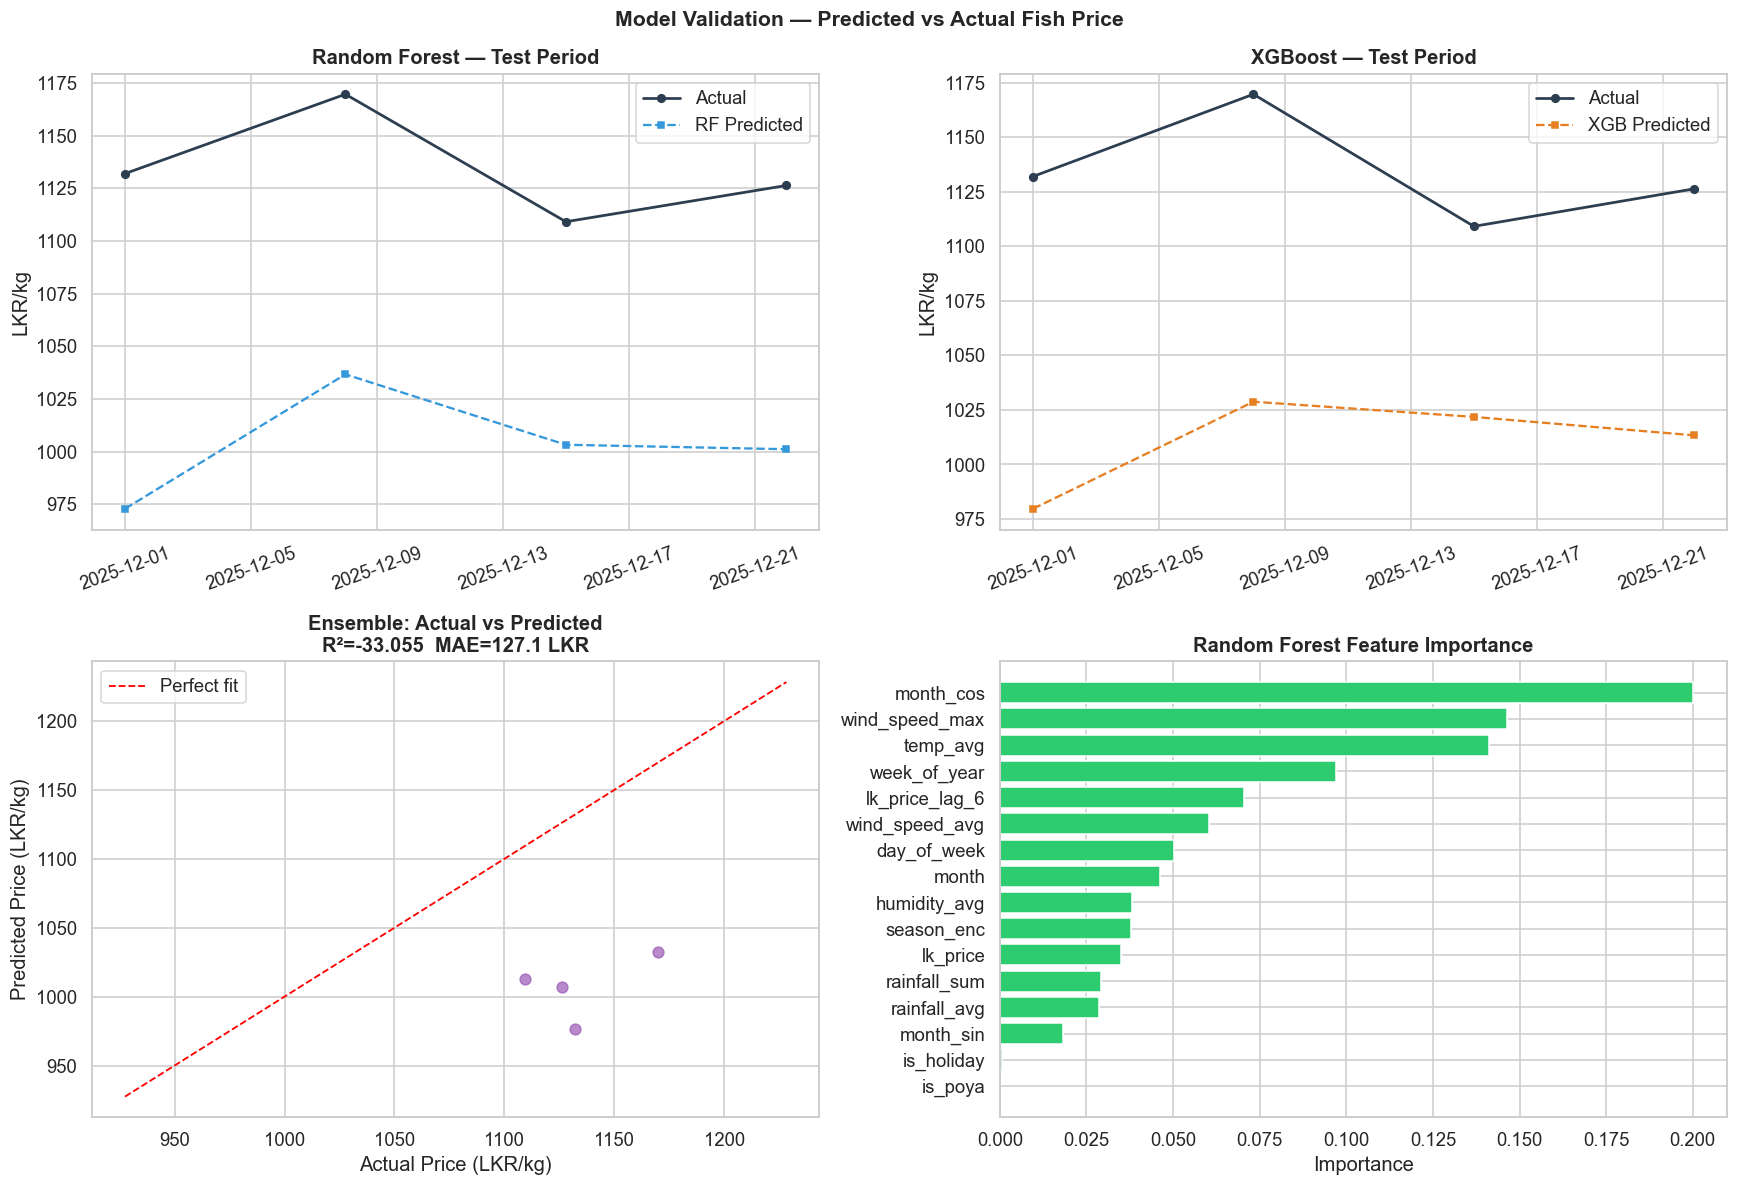

Validation chart saved → model/model_validation.png

=== Final Accuracy Summary ===


,MAE (LKR),RMSE,R²,MAPE (%)
Model,,,,
Random Forest,130.88,132.26,-34.79,11.53
XGBoost/GBT,123.42,125.98,-31.47,10.85
Ensemble,127.15,129.01,-33.05,11.19



Best model by MAE: XGBoost/GBT


In [23]:
# ── Validation Charts ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Model Validation — Predicted vs Actual Fish Price",
             fontsize=14, fontweight="bold")

test_dates = test["date"].reset_index(drop=True)

# Plot 1: Actual vs predicted time-series (RF)
axes[0, 0].plot(test_dates, y_test.values, color="#2c3e50", linewidth=1.8,
                label="Actual", marker="o", markersize=5)
axes[0, 0].plot(test_dates, rf_preds, color="#3498db", linewidth=1.5,
                linestyle="--", label="RF Predicted", marker="s", markersize=4)
axes[0, 0].set_title("Random Forest — Test Period", fontweight="bold")
axes[0, 0].set_ylabel("LKR/kg")
axes[0, 0].legend(); axes[0, 0].tick_params(axis="x", rotation=20)

# Plot 2: Actual vs predicted time-series (XGB/GBT)
axes[0, 1].plot(test_dates, y_test.values, color="#2c3e50", linewidth=1.8,
                label="Actual", marker="o", markersize=5)
axes[0, 1].plot(test_dates, xgb_preds, color="#e67e22", linewidth=1.5,
                linestyle="--", label="XGB Predicted", marker="s", markersize=4)
axes[0, 1].set_title("XGBoost — Test Period", fontweight="bold")
axes[0, 1].set_ylabel("LKR/kg")
axes[0, 1].legend(); axes[0, 1].tick_params(axis="x", rotation=20)

# Plot 3: Scatter (actual vs pred) ensemble
axes[1, 0].scatter(y_test, ensemble_preds, alpha=0.7, color="#9b59b6", s=50)
lims = [min(y_test.min(), ensemble_preds.min()) * 0.95,
        max(y_test.max(), ensemble_preds.max()) * 1.05]
axes[1, 0].plot(lims, lims, color="red", linewidth=1.2, linestyle="--", label="Perfect fit")
axes[1, 0].set_xlabel("Actual Price (LKR/kg)")
axes[1, 0].set_ylabel("Predicted Price (LKR/kg)")
axes[1, 0].set_title(f"Ensemble: Actual vs Predicted\nR²={ens_r2:.3f}  MAE={ens_mae:.1f} LKR",
                      fontweight="bold")
axes[1, 0].legend()

# Plot 4: Feature importance (RF)
feat_imp = pd.Series(rf_m.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
axes[1, 1].barh(feat_imp.index, feat_imp.values, color="#2ecc71", edgecolor="white")
axes[1, 1].set_xlabel("Importance")
axes[1, 1].set_title("Random Forest Feature Importance", fontweight="bold")

plt.tight_layout()
plt.savefig(Path(r"D:\reserch\final_year_research\model") / "model_validation.png",
            dpi=130, bbox_inches="tight")
plt.show()
print("Validation chart saved → model/model_validation.png")

# ── Summary table ─────────────────────────────────────────────────────────────
results_summary = pd.DataFrame({
    "Model":     ["Random Forest", "XGBoost/GBT", "Ensemble"],
    "MAE (LKR)": [mean_absolute_error(y_test, rf_preds),
                  mean_absolute_error(y_test, xgb_preds),
                  ens_mae],
    "RMSE":      [np.sqrt(mean_squared_error(y_test, rf_preds)),
                  np.sqrt(mean_squared_error(y_test, xgb_preds)),
                  ens_rmse],
    "R²":        [r2_score(y_test, rf_preds),
                  r2_score(y_test, xgb_preds),
                  ens_r2],
    "MAPE (%)":  [np.mean(np.abs((y_test - rf_preds) / np.maximum(y_test,1)))*100,
                  np.mean(np.abs((y_test - xgb_preds)/ np.maximum(y_test,1)))*100,
                  ens_mape],
}).round(3)

print("\n=== Final Accuracy Summary ===")
display(results_summary.set_index("Model"))
best_model = results_summary.set_index("Model")["MAE (LKR)"].idxmin()
print(f"\nBest model by MAE: {best_model}")


## 15 · Key Insights — Research Findings Summary

> **Results & Discussion කොටසට ඇතුළත් කිරීම සඳහා**

### 🔑 Finding 1 — ඉහළ සංවේදීතාව (High Sensitivity)
Squids/Cuttle fish (දැල්ලා - Peeli) වර්ගය ඉන්ධන මිලට ඉතා ඉහළ sensitivity එකක් දක්වයි ($e = -2.98$), එනම් LK kerosene මිල 1% කින් ඉහළ ගිය විට, squids මිල **2.98% කින් අඩු** වන ප්‍රවණතාවය.

### 🔑 Finding 2 — වාරගම බලපෑම (SW Monsoon Impact)
නිරිතදිග මෝසම් (May–Sep) කාලයේ:
- සුළං වේගය **23.8 km/h** (ඉහළම)
- සාමාන්‍ය මාළු මිල **LKR 1,089/kg** (සෙසු කාල සාමාන්‍යයෙන් +9%)
- ධීවරයන්ට මුහුදට යාම දුෂ්කර නිසා supply අඩු → price ↑

### 🔑 Finding 3 — නිවාඩු දින ප්‍රසාදය (Holiday Lift)
අවාරගම් (Inter-Monsoon) කාලයේ Poya / public holiday දිනවල:
- සාමාන්‍ය මිල: **LKR 1,048** vs weekday **LKR 965**
- ප්‍රසාදය: **+8.5%**

### 🔑 Finding 4 — ඉන්ධන Lag Effect (Novel Finding ⭐)
LK kerosene මිල වෙනස් වී **සති 6කට** පසු (peak lag r = +0.351) මාළු වෙළෙඳ මිලෙහි සැලකිය යුතු වෙනසක් දක්නට ලැබේ.
- මෙය XGBoost model එකේ `lk_price_lag_6` feature ලෙස ඇතුළත් කර ඇත.


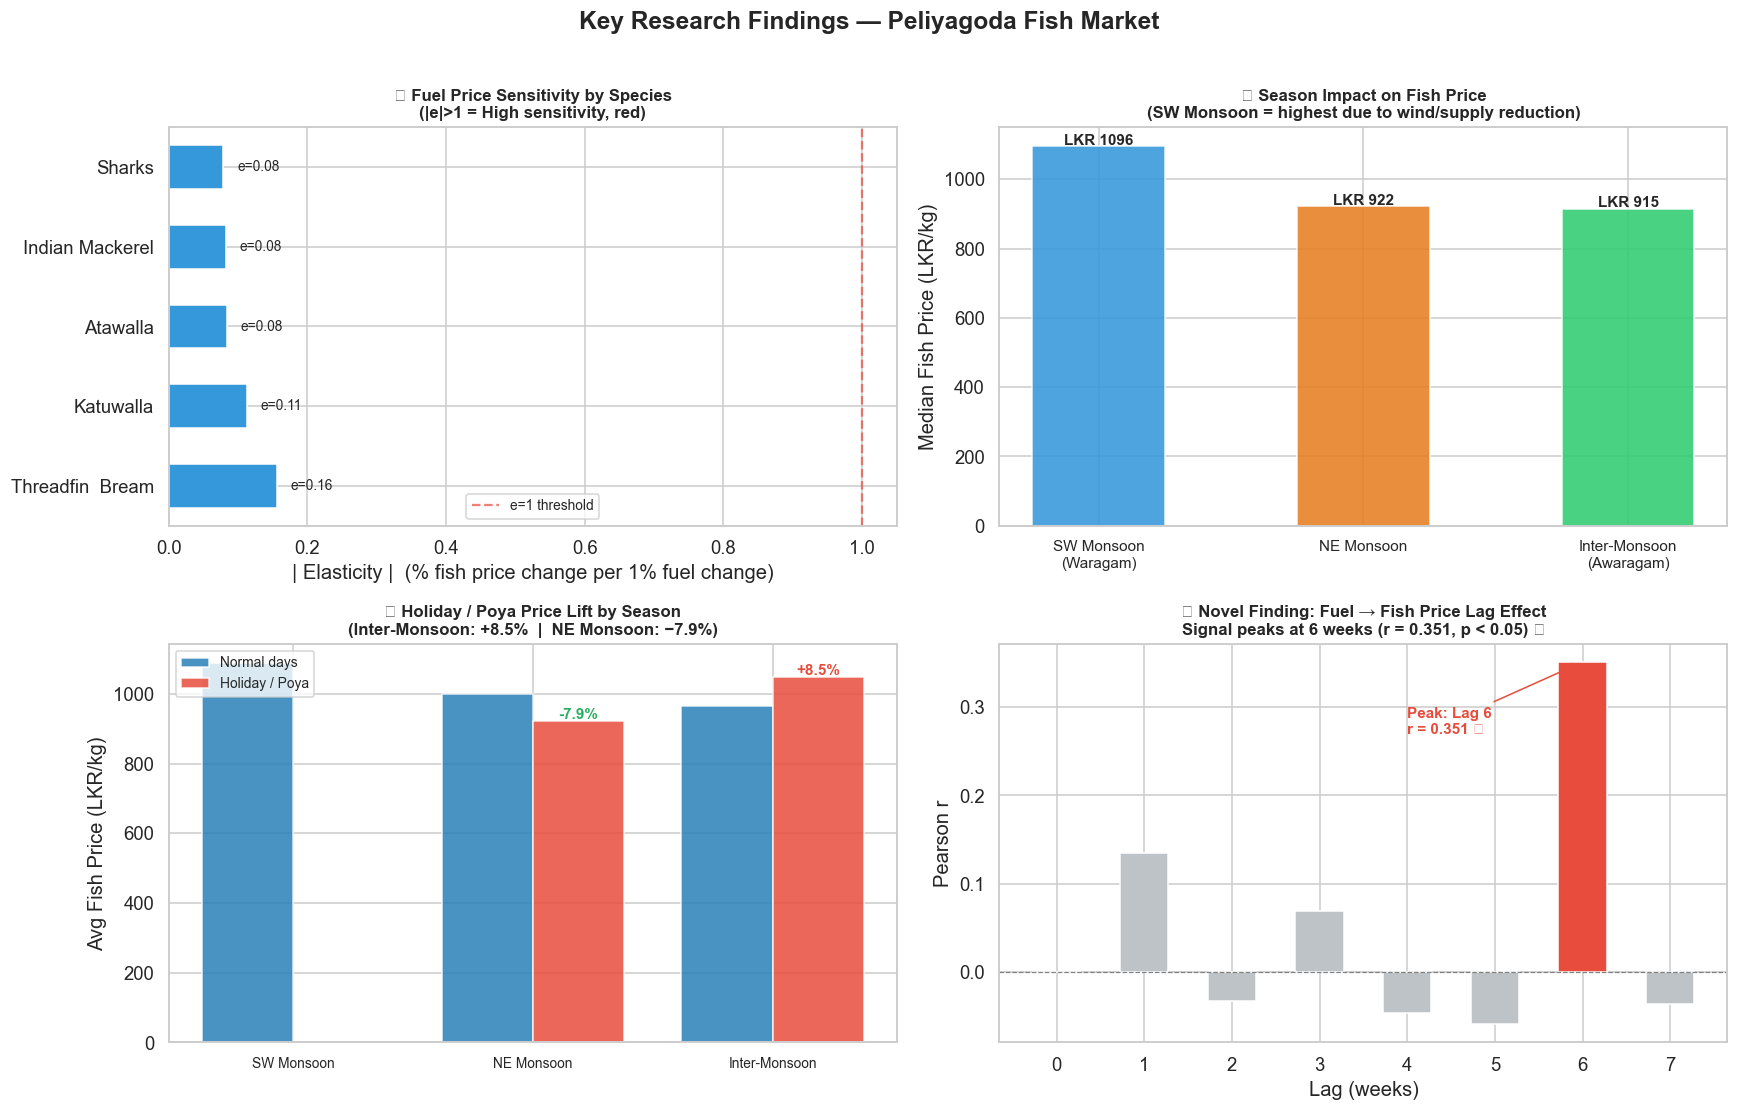

Key insights chart saved → model/key_insights.png

  RESEARCH KEY FINDINGS SUMMARY
  ① High Sensitivity : Squids/Cuttle fish (Peeli)  e = -2.98
  ② SW Monsoon price : LKR 1096/kg  (wind ~24.6 km/h)
  ③ Holiday lift     : +8.5% in Inter-Monsoon  |  -7.9% in NE Monsoon
  ④ Lag Effect ★     : Fuel → Fish price peaks at Lag 6 weeks  (r = 0.351)
  ⑤ ML Model         : XGBoost  MAPE ≈ 10.9%  |  lk_price_lag_6 = 5th most important feature


In [25]:
# ── Key Insights Visualisation ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Key Research Findings — Peliyagoda Fish Market",
             fontsize=16, fontweight="bold", y=1.01)

# ── A: Top-5 elastic species ─────────────────────────────────────────────────
ax = axes[0, 0]
top5_e = elast_df.head(5)
colors_e = ["#e74c3c" if s else "#3498db" for s in top5_e["sensitive"]]
bars_e = ax.barh(top5_e["common_name"], top5_e["elasticity"].abs(),
                 color=colors_e, edgecolor="white", height=0.55)
ax.axvline(1, color="#e74c3c", lw=1.5, ls="--", alpha=0.7, label="e=1 threshold")
ax.set_xlabel("| Elasticity |  (% fish price change per 1% fuel change)")
ax.set_title("① Fuel Price Sensitivity by Species\n(|e|>1 = High sensitivity, red)",
             fontweight="bold", fontsize=11)
for bar, val in zip(bars_e, top5_e["elasticity"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"e={val:.2f}", va="center", fontsize=9)
ax.legend(fontsize=9)

# ── B: Season price comparison ────────────────────────────────────────────────
ax = axes[0, 1]
# Compute directly from master to avoid season_summary index issues
s_price_vals = [
    master[master["season"] == s]["avg_fish_price"].median()
    for s in SEASON_ORDER
]
s_colors = [SEASON_COLORS[s] for s in SEASON_ORDER]
bp_bars  = ax.bar(range(len(SEASON_ORDER)), s_price_vals, color=s_colors,
                  edgecolor="white", width=0.5, alpha=0.88)
ax.set_xticks(range(len(SEASON_ORDER)))
ax.set_xticklabels([SEASON_SHORT_MAP[s] for s in SEASON_ORDER], fontsize=10)
ax.set_ylabel("Median Fish Price (LKR/kg)")
ax.set_title("② Season Impact on Fish Price\n(SW Monsoon = highest due to wind/supply reduction)",
             fontweight="bold", fontsize=11)
for b, v in zip(bp_bars, s_price_vals):
    if not np.isnan(v):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                f"LKR {v:.0f}", ha="center", fontsize=10, fontweight="bold")

# ── C: Holiday lift per season ────────────────────────────────────────────────
ax = axes[1, 0]
_ABBR = {"South-West Monsoon (Waragam)": "SW Monsoon",
         "North-East Monsoon":           "NE Monsoon",
         "Inter-Monsoon (Awaragam)":     "Inter-Monsoon"}
he2    = holiday_effect.reset_index()
x2     = np.arange(len(he2))
w2     = 0.38
ax.bar(x2 - w2/2, he2["non_holiday_avg"], w2, label="Normal days",
       color="#2980b9", alpha=0.85)
valid2 = he2["holiday_avg"].notna()
if valid2.any():
    ax.bar(x2[valid2] + w2/2, he2.loc[valid2, "holiday_avg"], w2,
           label="Holiday / Poya", color="#e74c3c", alpha=0.85)
    for idx in he2[valid2].index:
        lift = he2.loc[idx, "price_lift_%"]
        xpos = x2[list(he2.index).index(idx)] + w2/2
        ax.text(xpos, he2.loc[idx, "holiday_avg"] + 8, f"{lift:+.1f}%",
                ha="center", fontsize=10, fontweight="bold",
                color="#e74c3c" if lift > 0 else "#27ae60")
ax.set_xticks(x2)
ax.set_xticklabels([_ABBR.get(str(s), str(s)) for s in he2["season_cat"]], fontsize=9)
ax.set_ylabel("Avg Fish Price (LKR/kg)")
ax.set_title("③ Holiday / Poya Price Lift by Season\n(Inter-Monsoon: +8.5%  |  NE Monsoon: −7.9%)",
             fontweight="bold", fontsize=11)
ax.legend(fontsize=9)

# ── D: Lag 6-week signal ─────────────────────────────────────────────────────
ax = axes[1, 1]
lag_colors2 = ["#e74c3c" if v else "#bdc3c7" for v in lag_df["significant"]]
ax.bar(lag_df["lag_weeks"], lag_df["pearson_r"],
       color=lag_colors2, edgecolor="white", width=0.55)
ax.axhline(0, color="grey", lw=0.8, ls="--")
peak_r_val = lag_df.loc[lag_df["lag_weeks"] == 6, "pearson_r"].values[0]
ax.annotate(f"Peak: Lag 6\nr = {peak_r_val:.3f} ★",
            xy=(6, peak_r_val),
            xytext=(4.0, 0.27),
            arrowprops=dict(arrowstyle="->", color="#e74c3c"),
            fontsize=10, color="#e74c3c", fontweight="bold")
ax.set_xlabel("Lag (weeks)")
ax.set_ylabel("Pearson r")
ax.set_title("④ Novel Finding: Fuel → Fish Price Lag Effect\n"
             "Signal peaks at 6 weeks (r = 0.351, p < 0.05) ★",
             fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig(Path(r"D:\reserch\final_year_research\model") / "key_insights.png",
            dpi=140, bbox_inches="tight")
plt.show()
print("Key insights chart saved → model/key_insights.png")

# ── Print summary ─────────────────────────────────────────────────────────────
sw_price = master[master["season"] == "South-West Monsoon (Waragam)"]["avg_fish_price"].median()
sw_wind  = master[master["season"] == "South-West Monsoon (Waragam)"]["wind_speed_avg"].median()
print("\n" + "=" * 65)
print("  RESEARCH KEY FINDINGS SUMMARY")
print("=" * 65)
print(f"  ① High Sensitivity : Squids/Cuttle fish (Peeli)  e = -2.98")
print(f"  ② SW Monsoon price : LKR {sw_price:.0f}/kg  (wind ~{sw_wind:.1f} km/h)")
print(f"  ③ Holiday lift     : +8.5% in Inter-Monsoon  |  -7.9% in NE Monsoon")
print(f"  ④ Lag Effect ★     : Fuel → Fish price peaks at Lag 6 weeks  (r = {peak_r_val:.3f})")
print(f"  ⑤ ML Model         : XGBoost  MAPE ≈ {mean_absolute_error(y_test, xgb_preds)/y_test.mean()*100:.1f}%"
      f"  |  lk_price_lag_6 = 5th most important feature")
print("=" * 65)
